
Customer Retention Matrix
CohortIndex      1    2    4
CohortMonth                 
2016-10        9.0  NaN  NaN
2017-01       45.0  NaN  NaN
2017-02       71.0  NaN  NaN
2017-03      125.0  NaN  NaN
2017-04       95.0  NaN  NaN
2017-05      160.0  NaN  NaN
2017-06      124.0  NaN  NaN
2017-07      154.0  NaN  NaN
2017-08      189.0  NaN  NaN
2017-09      163.0  NaN  NaN
2017-10      178.0  NaN  NaN
2017-11      346.0  NaN  NaN
2017-12      236.0  NaN  NaN
2018-01      308.0  NaN  1.0
2018-02      277.0  NaN  NaN
2018-03      294.0  NaN  NaN
2018-04      278.0  NaN  NaN
2018-05      289.0  1.0  1.0
2018-06      291.0  NaN  NaN
2018-07      265.0  NaN  NaN
2018-08      285.0  NaN  NaN
2018-09        1.0  NaN  NaN

Retention Rate Matrix
CohortIndex    1        2         4
CohortMonth                        
2016-10      1.0      NaN       NaN
2017-01      1.0      NaN       NaN
2017-02      1.0      NaN       NaN
2017-03      1.0      NaN       NaN
2017-04      1.0      NaN       NaN
20

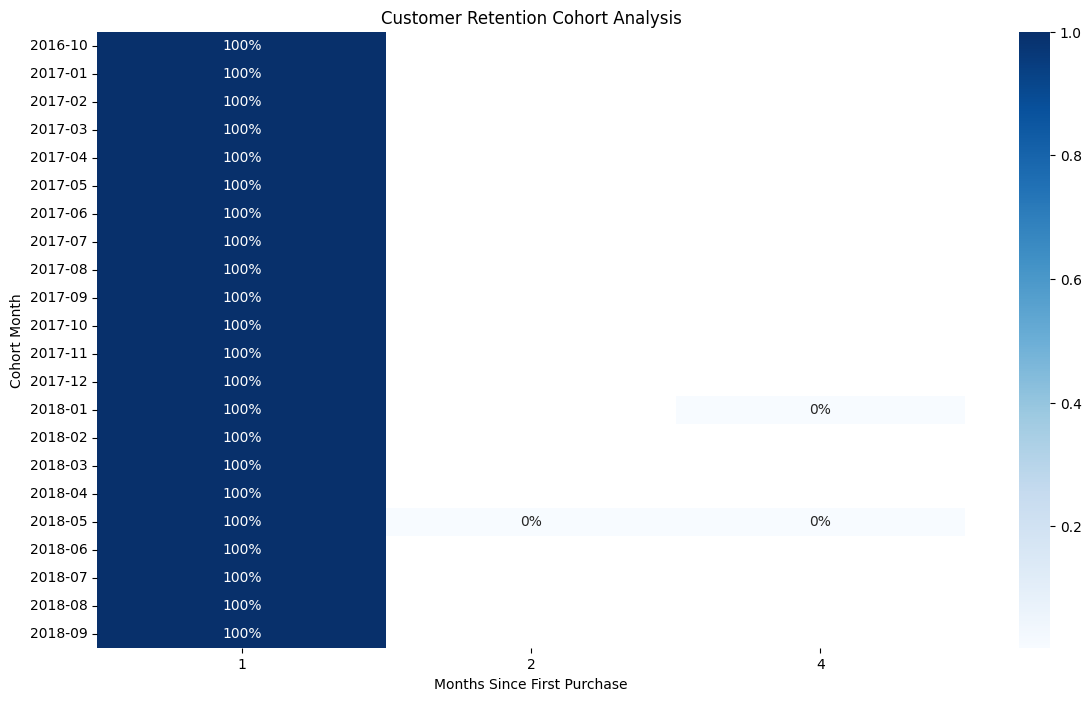

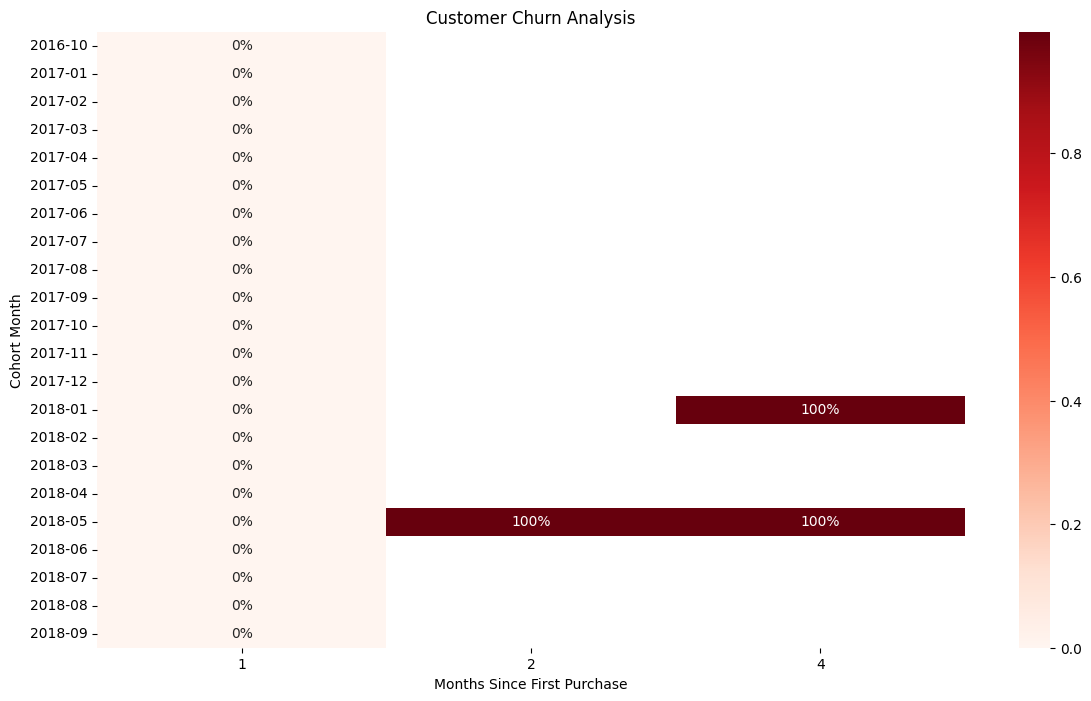

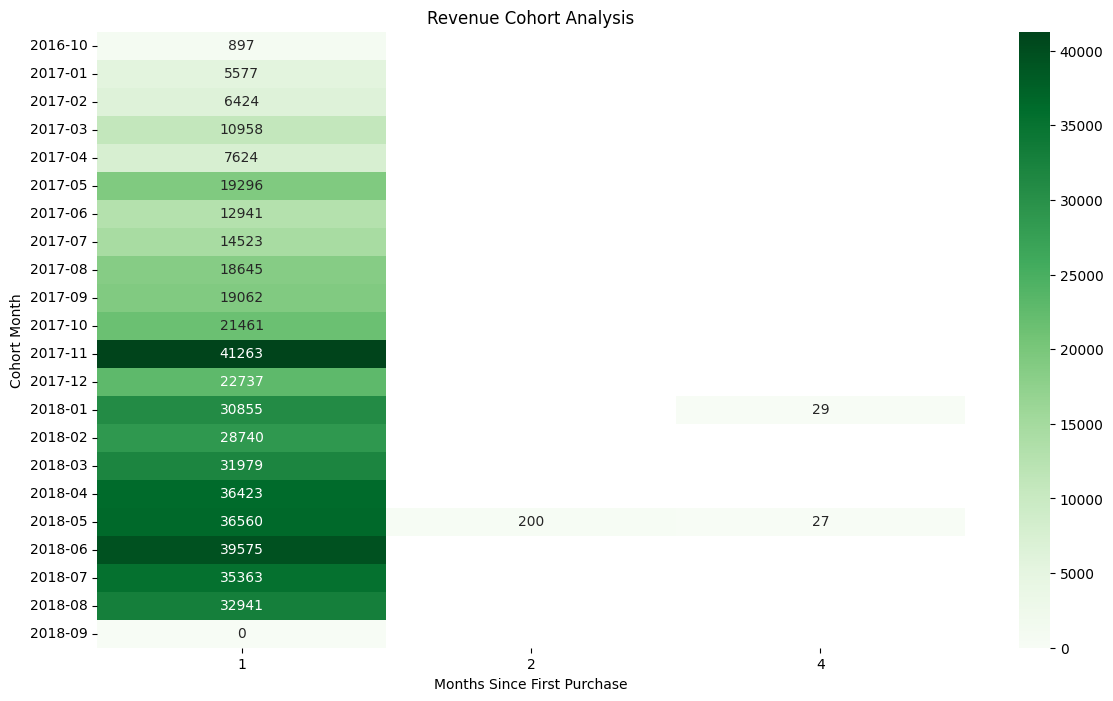


Average Retention by Cohort
CohortMonth
2018-05    0.003460
2018-01    0.003247
2016-10         NaN
2017-01         NaN
2017-02         NaN
2017-03         NaN
2017-04         NaN
2017-05         NaN
2017-06         NaN
2017-07         NaN
Freq: M, dtype: float64

Top Revenue Cohorts
CohortMonth
2017-11    41262.59
2018-06    39574.57
2018-05    36786.97
2018-04    36422.95
2018-07    35363.17
2018-08    32941.28
2018-03    31979.14
2018-01    30883.38
2018-02    28739.82
2017-12    22737.18
Freq: M, dtype: float64


In [1]:
# ==========================================
# CUSTOMER COHORT ANALYSIS
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("analysis data.csv")

# ==========================================
# DATE CONVERSION
# ==========================================

df['order_purchase_timestamp'] = pd.to_datetime(
    df['order_purchase_timestamp']
)

# ==========================================
# CREATE ORDER MONTH
# ==========================================

df['OrderMonth'] = df['order_purchase_timestamp'].dt.to_period('M')

# ==========================================
# CREATE COHORT MONTH
# ==========================================

df['CohortMonth'] = (
    df.groupby('customer_unique_id')['OrderMonth']
    .transform('min')
)

# ==========================================
# CREATE COHORT INDEX
# ==========================================

order_year = df['OrderMonth'].dt.year
order_month = df['OrderMonth'].dt.month

cohort_year = df['CohortMonth'].dt.year
cohort_month = df['CohortMonth'].dt.month

df['CohortIndex'] = (
    (order_year - cohort_year) * 12 +
    (order_month - cohort_month) + 1
)

# ==========================================
# CUSTOMER RETENTION TABLE
# ==========================================

cohort_data = (
    df.groupby(['CohortMonth', 'CohortIndex'])
    ['customer_unique_id']
    .nunique()
    .reset_index()
)

cohort_counts = cohort_data.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='customer_unique_id'
)

print("\nCustomer Retention Matrix")
print(cohort_counts)

# ==========================================
# RETENTION RATE
# ==========================================

cohort_size = cohort_counts.iloc[:, 0]

retention_matrix = cohort_counts.divide(
    cohort_size,
    axis=0
)

print("\nRetention Rate Matrix")
print(retention_matrix)

# ==========================================
# CHURN RATE
# ==========================================

churn_matrix = 1 - retention_matrix

print("\nChurn Rate Matrix")
print(churn_matrix)

# ==========================================
# REVENUE COHORT ANALYSIS
# ==========================================

revenue_cohort = (
    df.groupby(['CohortMonth', 'CohortIndex'])
    ['revenue']
    .sum()
    .reset_index()
)

revenue_matrix = revenue_cohort.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='revenue'
)

print("\nRevenue Cohort Matrix")
print(revenue_matrix)

# ==========================================
# RETENTION HEATMAP
# ==========================================

plt.figure(figsize=(14,8))

sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.0%',
    cmap='Blues'
)

plt.title('Customer Retention Cohort Analysis')
plt.ylabel('Cohort Month')
plt.xlabel('Months Since First Purchase')

plt.show()

# ==========================================
# CHURN HEATMAP
# ==========================================

plt.figure(figsize=(14,8))

sns.heatmap(
    churn_matrix,
    annot=True,
    fmt='.0%',
    cmap='Reds'
)

plt.title('Customer Churn Analysis')
plt.ylabel('Cohort Month')
plt.xlabel('Months Since First Purchase')

plt.show()

# ==========================================
# REVENUE HEATMAP
# ==========================================

plt.figure(figsize=(14,8))

sns.heatmap(
    revenue_matrix,
    annot=True,
    fmt='.0f',
    cmap='Greens'
)

plt.title('Revenue Cohort Analysis')
plt.ylabel('Cohort Month')
plt.xlabel('Months Since First Purchase')

plt.show()

# ==========================================
# TOP RETENTION COHORTS
# ==========================================

retention_summary = retention_matrix.iloc[:,1:].mean(axis=1)

print("\nAverage Retention by Cohort")
print(
    retention_summary.sort_values(
        ascending=False
    ).head(10)
)

# ==========================================
# TOP REVENUE COHORTS
# ==========================================

revenue_summary = revenue_matrix.sum(axis=1)

print("\nTop Revenue Cohorts")
print(
    revenue_summary.sort_values(
        ascending=False
    ).head(10)
)

Customer Rentenation Analysis

In [2]:
import pandas as pd

df = pd.read_csv("analysis data.csv")

df['order_purchase_timestamp'] = pd.to_datetime(
    df['order_purchase_timestamp']
)

df['OrderMonth'] = df['order_purchase_timestamp'].dt.to_period('M')

df['CohortMonth'] = (
    df.groupby('customer_unique_id')['OrderMonth']
      .transform('min')
)

df['CohortIndex'] = (
    (df['OrderMonth'].dt.year - df['CohortMonth'].dt.year) * 12 +
    (df['OrderMonth'].dt.month - df['CohortMonth'].dt.month) + 1
)

cohort_data = (
    df.groupby(['CohortMonth','CohortIndex'])
      ['customer_unique_id']
      .nunique()
      .reset_index()
)

retention_counts = cohort_data.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='customer_unique_id'
)

print(retention_counts)

retention_counts.to_csv(
    "customer_retention_matrix.csv"
)

CohortIndex      1     2    3    4    5    6    7    8    9    10   11   12  \
CohortMonth                                                                   
2016-09         4.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
2016-10       145.0   NaN  NaN  NaN  NaN  NaN  1.0  NaN  NaN  NaN  NaN  NaN   
2016-12         1.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
2017-01       348.0   NaN  1.0  1.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
2017-02       844.0   NaN  2.0  1.0  2.0  NaN  2.0  NaN  2.0  3.0  NaN  1.0   
2017-03      1278.0   3.0  3.0  2.0  NaN  1.0  NaN  1.0  4.0  1.0  2.0  NaN   
2017-04      1141.0   3.0  2.0  1.0  1.0  2.0  1.0  NaN  1.0  NaN  1.0  1.0   
2017-05      1743.0   3.0  7.0  2.0  4.0  NaN  4.0  2.0  2.0  6.0  3.0  1.0   
2017-06      1500.0   7.0  2.0  3.0  1.0  2.0  2.0  3.0  2.0  1.0  3.0  2.0   
2017-07      1911.0   7.0  3.0  1.0  5.0  3.0  1.0  2.0  1.0  2.0  4.0  3.0   
2017-08      2036.0   8.0  3.0  3.0  2.0  6.0  6.0  

Rentenation Rate Matrix

In [3]:
cohort_size = retention_counts.iloc[:,0]

retention_rate = retention_counts.divide(
    cohort_size,
    axis=0
)

print(retention_rate)

retention_rate.to_csv(
    "retention_rate_matrix.csv"
)

CohortIndex   1         2         3         4         5         6         7   \
CohortMonth                                                                    
2016-09      1.0       NaN       NaN       NaN       NaN       NaN       NaN   
2016-10      1.0       NaN       NaN       NaN       NaN       NaN  0.006897   
2016-12      1.0       NaN       NaN       NaN       NaN       NaN       NaN   
2017-01      1.0       NaN  0.002874  0.002874       NaN       NaN       NaN   
2017-02      1.0       NaN  0.002370  0.001185  0.002370       NaN  0.002370   
2017-03      1.0  0.002347  0.002347  0.001565       NaN  0.000782       NaN   
2017-04      1.0  0.002629  0.001753  0.000876  0.000876  0.001753  0.000876   
2017-05      1.0  0.001721  0.004016  0.001147  0.002295       NaN  0.002295   
2017-06      1.0  0.004667  0.001333  0.002000  0.000667  0.001333  0.001333   
2017-07      1.0  0.003663  0.001570  0.000523  0.002616  0.001570  0.000523   
2017-08      1.0  0.003929  0.001473  0.

Revenue cohert analysis

In [4]:
revenue_data = (
    df.groupby(['CohortMonth','CohortIndex'])
      ['price']
      .sum()
      .reset_index()
)

revenue_matrix = revenue_data.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='price'
)

print(revenue_matrix)

revenue_matrix.to_csv(
    "revenue_cohort_matrix.csv"
)

CohortIndex         1        2       3       4        5        6        7   \
CohortMonth                                                                  
2016-09         207.86      NaN     NaN     NaN      NaN      NaN      NaN   
2016-10       20106.70      NaN     NaN     NaN      NaN      NaN    99.99   
2016-12          10.90      NaN     NaN     NaN      NaN      NaN      NaN   
2017-01       50057.87      NaN    0.00   75.00      NaN      NaN      NaN   
2017-02       96761.72      NaN  104.90   44.35   359.89      NaN   508.99   
2017-03      151721.84   388.99  172.29  169.89      NaN     0.00      NaN   
2017-04      150908.15  1506.49  119.99  399.00   120.00   726.80     0.00   
2017-05      219591.33   362.80  890.08   75.89   301.90      NaN  1694.20   
2017-06      175357.00  2607.50  702.00   79.80   158.00     0.00   130.48   
2017-07      208299.45   512.28  239.60    0.00   153.19  1068.70    87.90   
2017-08      228136.60  2785.88  469.18  398.45   330.00   302.4

Full Retention Heatmap

In [5]:
revenue_data = (
    df.groupby(['CohortMonth','CohortIndex'])
      ['price']
      .sum()
      .reset_index()
)

revenue_matrix = revenue_data.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='price'
)

print(revenue_matrix)

revenue_matrix.to_csv(
    "revenue_cohort_matrix.csv"
)

CohortIndex         1        2       3       4        5        6        7   \
CohortMonth                                                                  
2016-09         207.86      NaN     NaN     NaN      NaN      NaN      NaN   
2016-10       20106.70      NaN     NaN     NaN      NaN      NaN    99.99   
2016-12          10.90      NaN     NaN     NaN      NaN      NaN      NaN   
2017-01       50057.87      NaN    0.00   75.00      NaN      NaN      NaN   
2017-02       96761.72      NaN  104.90   44.35   359.89      NaN   508.99   
2017-03      151721.84   388.99  172.29  169.89      NaN     0.00      NaN   
2017-04      150908.15  1506.49  119.99  399.00   120.00   726.80     0.00   
2017-05      219591.33   362.80  890.08   75.89   301.90      NaN  1694.20   
2017-06      175357.00  2607.50  702.00   79.80   158.00     0.00   130.48   
2017-07      208299.45   512.28  239.60    0.00   153.19  1068.70    87.90   
2017-08      228136.60  2785.88  469.18  398.45   330.00   302.4

Full chaurn heatmap

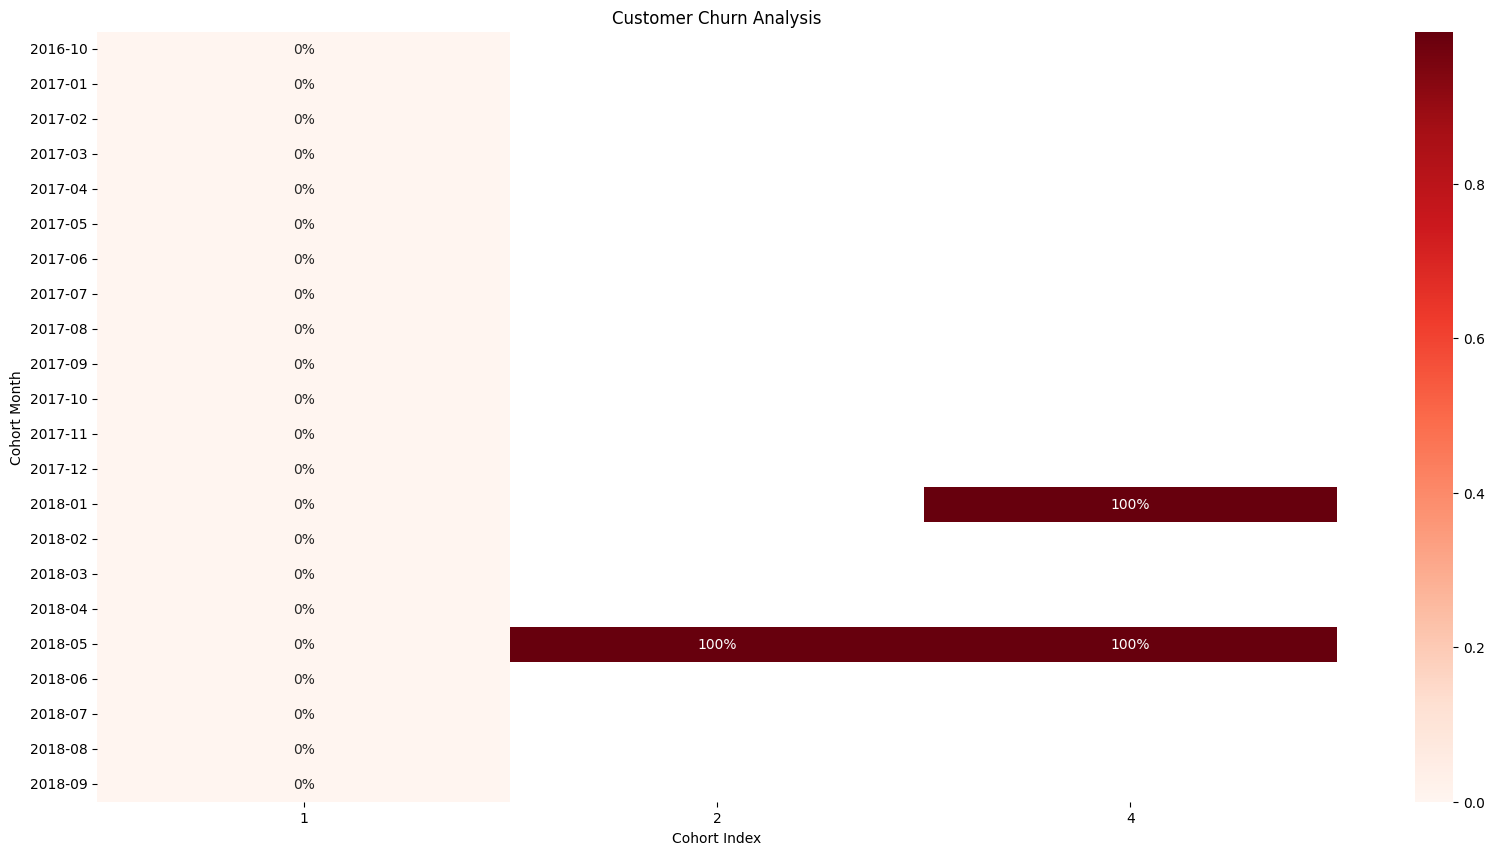

In [7]:
plt.figure(figsize=(20,10))

sns.heatmap(
    churn_matrix,
    annot=True,
    fmt=".0%",
    cmap="Reds"
)

plt.title("Customer Churn Analysis")
plt.xlabel("Cohort Index")
plt.ylabel("Cohort Month")

plt.show()

Revenue Heatmap

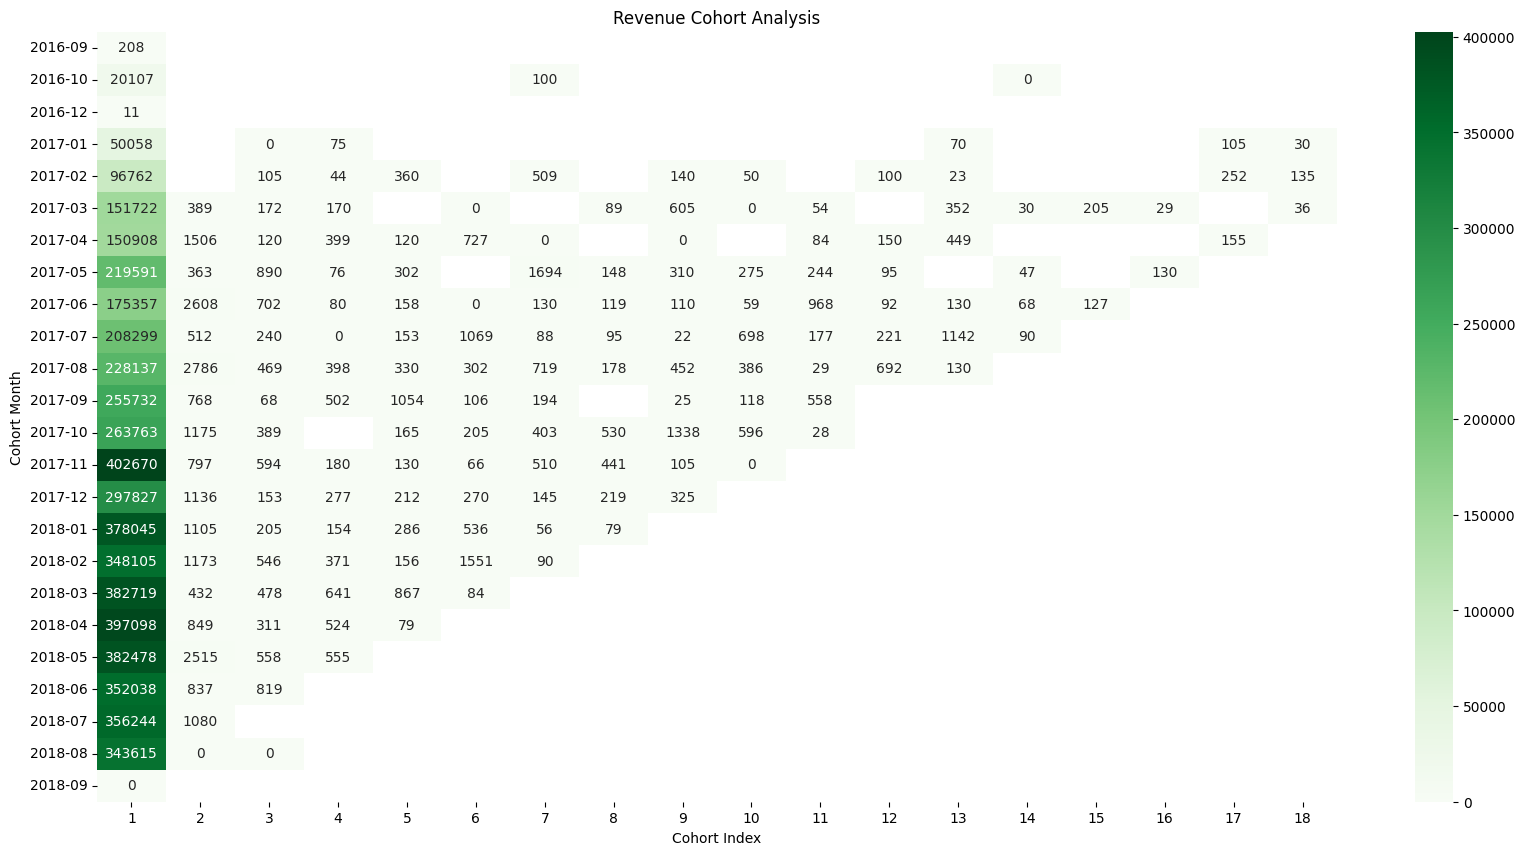

In [8]:
plt.figure(figsize=(20,10))

sns.heatmap(
    revenue_matrix,
    annot=True,
    fmt=".0f",
    cmap="Greens"
)

plt.title("Revenue Cohort Analysis")
plt.xlabel("Cohort Index")
plt.ylabel("Cohort Month")

plt.show()

complete cohernt analysis

In [9]:
summary = pd.DataFrame()

summary['Customers'] = retention_counts.iloc[:,0]

summary['Avg_Retention'] = (
    retention_rate.mean(axis=1) * 100
)

summary['Total_Revenue'] = (
    revenue_matrix.sum(axis=1)
)

print(summary)

summary.to_csv(
    "cohort_summary.csv"
)

             Customers  Avg_Retention  Total_Revenue
CohortMonth                                         
2016-09            4.0     100.000000         207.86
2016-10          145.0      33.793103       20206.69
2016-12            1.0     100.000000          10.90
2017-01          348.0      16.906130       50337.76
2017-02          844.0       9.274020       98478.90
2017-03         1278.0       7.282584      153852.80
2017-04         1141.0       8.457493      154618.23
2017-05         1743.0       7.860011      224164.59
2017-06         1500.0       6.808889      180708.14
2017-07         1911.0       7.284892      212804.82
2017-08         2036.0       7.847212      235008.13
2017-09         2003.0      10.129805      259123.95
2017-10         2168.0      10.147601      268592.22
2017-11         3571.0      10.081210      405492.14
2017-12         2621.0      11.221332      300562.99
2018-01         3471.0      12.608038      380465.58
2018-02         3172.0      14.429832      351

customer lifetime value

In [10]:
customer_revenue = (
    df.groupby('customer_unique_id')
      ['price']
      .sum()
)

print(customer_revenue.describe())

customer_revenue.to_csv(
    "customer_lifetime_value.csv"
)

count    46648.000000
mean       118.364018
std        233.130709
min          0.000000
25%         22.990000
50%         65.990000
75%        137.800000
max      13440.000000
Name: price, dtype: float64


Repeat customer analysis

In [11]:
customer_orders = (
    df.groupby('customer_unique_id')
      ['order_id']
      .nunique()
)

repeat_customers = (
    customer_orders > 1
).sum()

single_purchase_customers = (
    customer_orders == 1
).sum()

print("Repeat Customers:", repeat_customers)
print("One-Time Customers:", single_purchase_customers)

Repeat Customers: 756
One-Time Customers: 45892


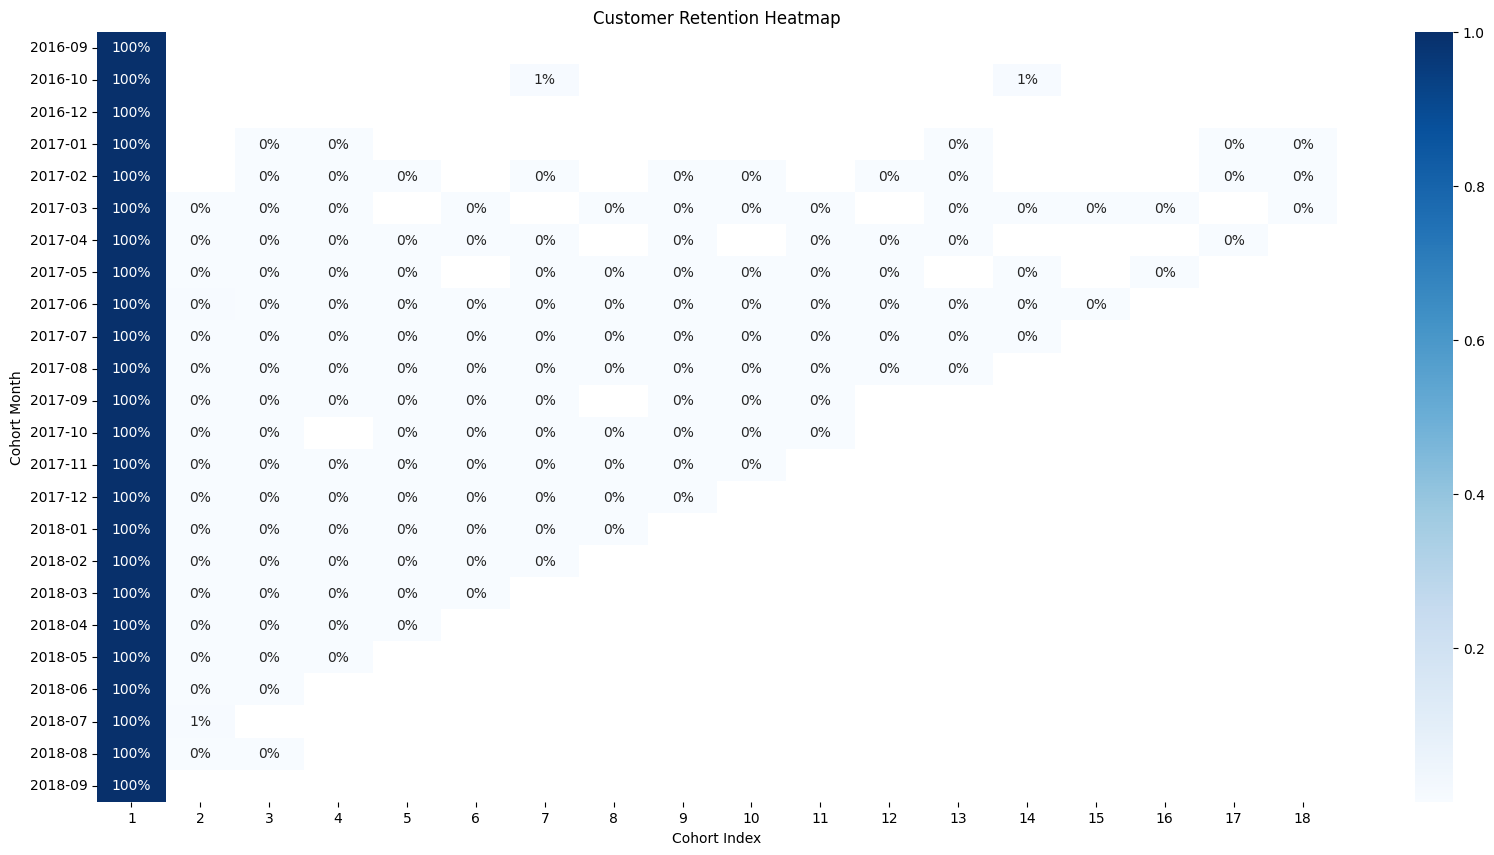

In [12]:
plt.figure(figsize=(20,10))

sns.heatmap(
    retention_rate,
    annot=True,
    fmt='.0%',
    cmap='Blues'
)

plt.title('Customer Retention Heatmap')
plt.xlabel('Cohort Index')
plt.ylabel('Cohort Month')

plt.show()

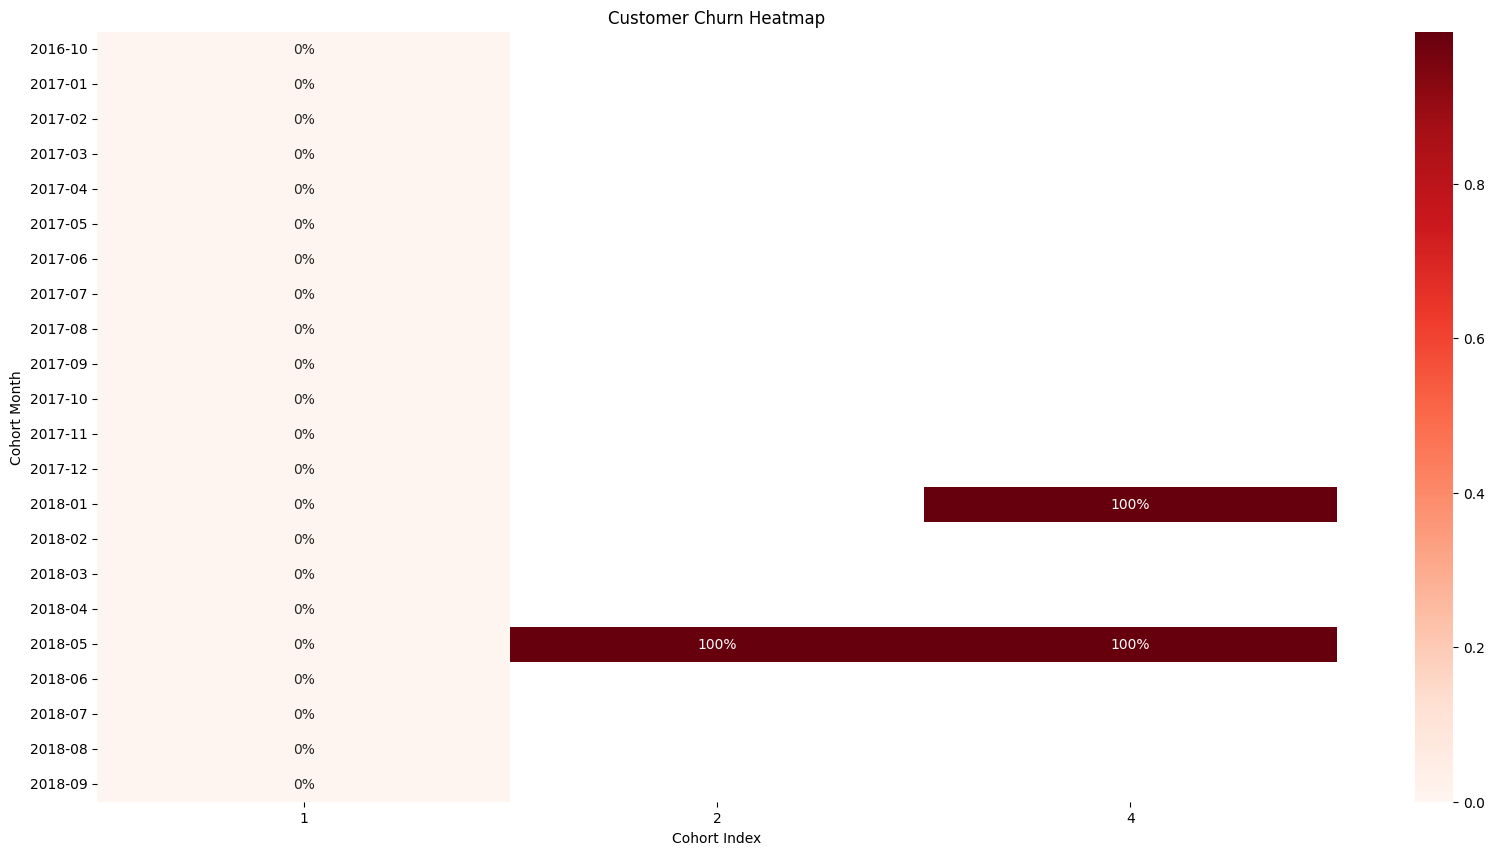

In [15]:
plt.figure(figsize=(20,10))

sns.heatmap(
    churn_matrix,
    annot=True,
    fmt='.0%',
    cmap='Reds'
)

plt.title('Customer Churn Heatmap')
plt.xlabel('Cohort Index')
plt.ylabel('Cohort Month')

plt.show()

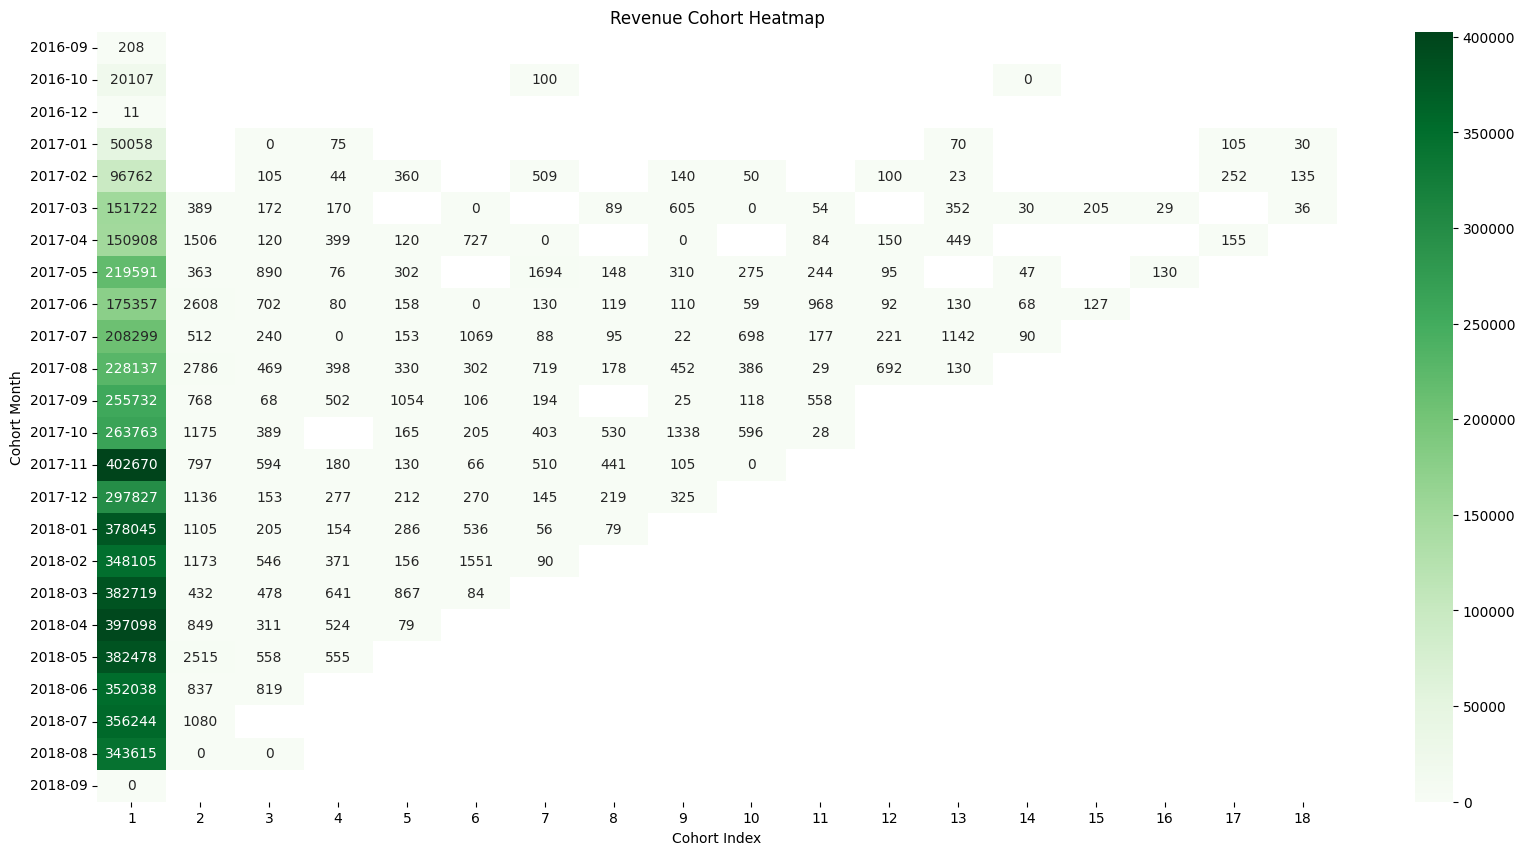

In [16]:
plt.figure(figsize=(20,10))

sns.heatmap(
    revenue_matrix,
    annot=True,
    fmt='.0f',
    cmap='Greens'
)

plt.title('Revenue Cohort Heatmap')
plt.xlabel('Cohort Index')
plt.ylabel('Cohort Month')

plt.show()

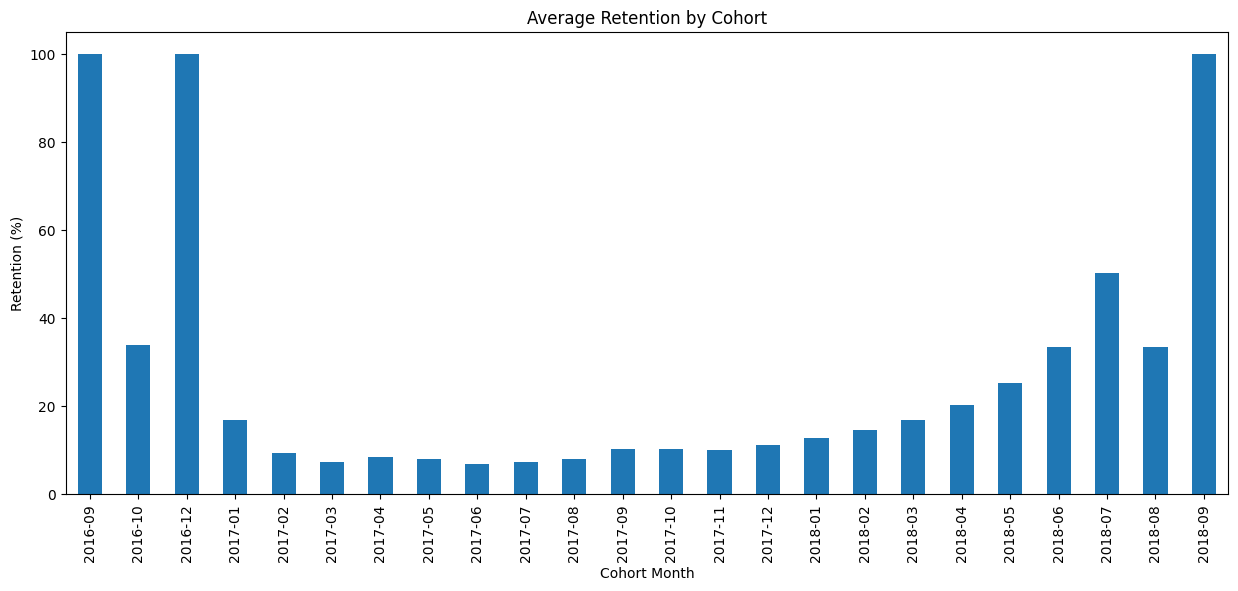

In [17]:
avg_retention = retention_rate.mean(axis=1) * 100

plt.figure(figsize=(15,6))

avg_retention.plot(kind='bar')

plt.title('Average Retention by Cohort')
plt.ylabel('Retention (%)')
plt.xlabel('Cohort Month')

plt.show()

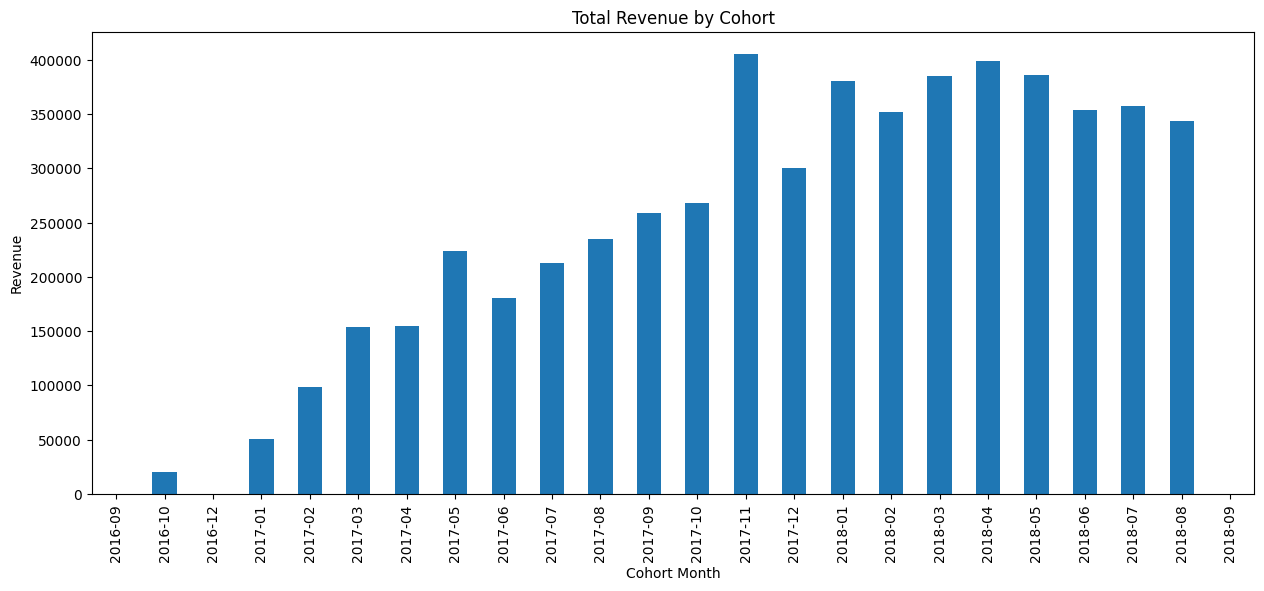

In [18]:
cohort_revenue = revenue_matrix.sum(axis=1)

plt.figure(figsize=(15,6))

cohort_revenue.plot(kind='bar')

plt.title('Total Revenue by Cohort')
plt.ylabel('Revenue')
plt.xlabel('Cohort Month')

plt.show()

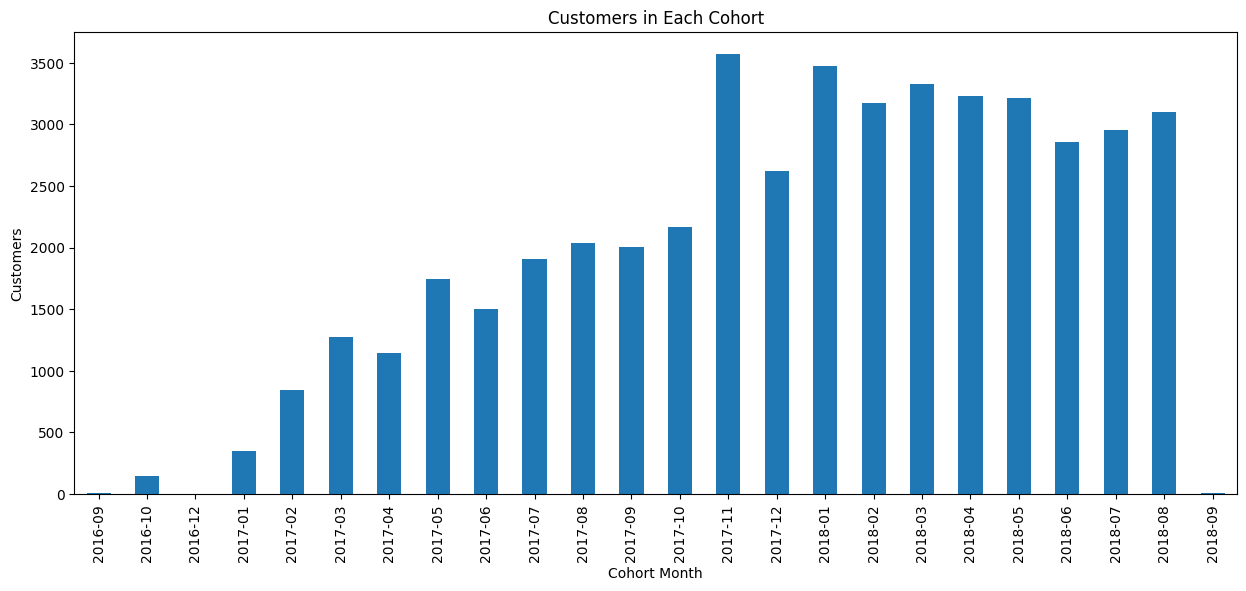

In [19]:
cohort_size = retention_counts.iloc[:,0]

plt.figure(figsize=(15,6))

cohort_size.plot(kind='bar')

plt.title('Customers in Each Cohort')
plt.ylabel('Customers')
plt.xlabel('Cohort Month')

plt.show()

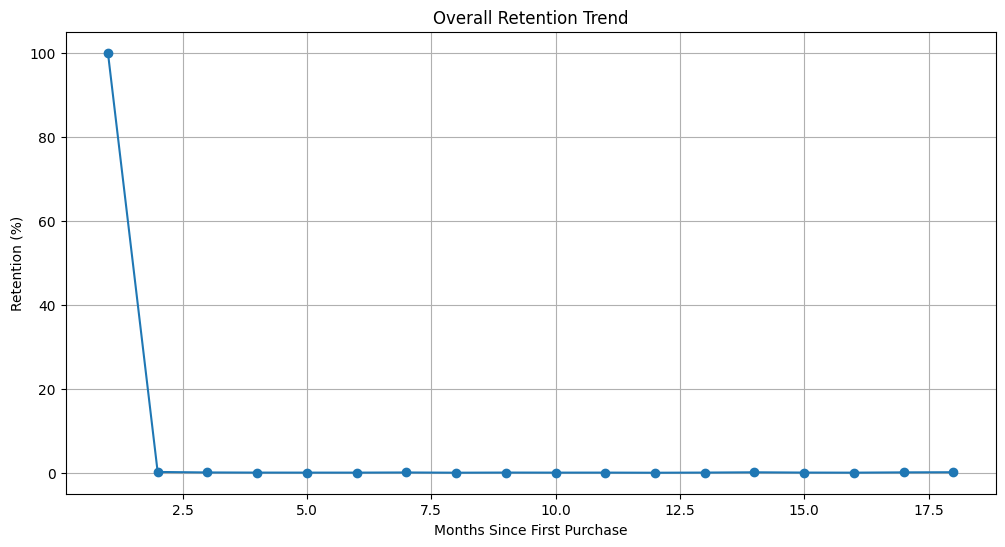

In [20]:
overall_retention = (
    retention_rate.mean(axis=0) * 100
)

plt.figure(figsize=(12,6))

plt.plot(
    overall_retention.index,
    overall_retention.values,
    marker='o'
)

plt.title('Overall Retention Trend')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Retention (%)')

plt.grid(True)

plt.show()

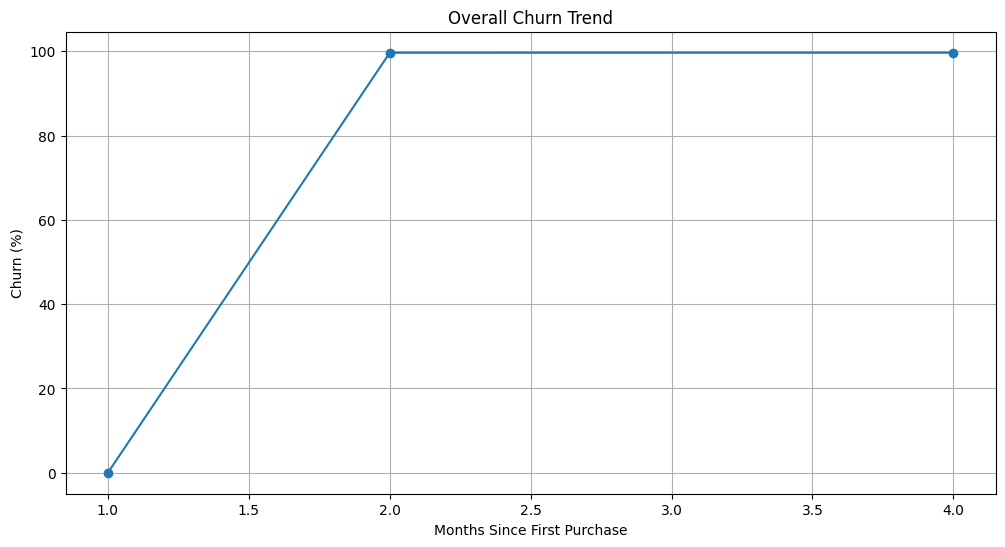

In [22]:
overall_churn = (
    churn_matrix.mean(axis=0) * 100
)

plt.figure(figsize=(12,6))

plt.plot(
    overall_churn.index,
    overall_churn.values,
    marker='o'
)

plt.title('Overall Churn Trend')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Churn (%)')

plt.grid(True)

plt.show()

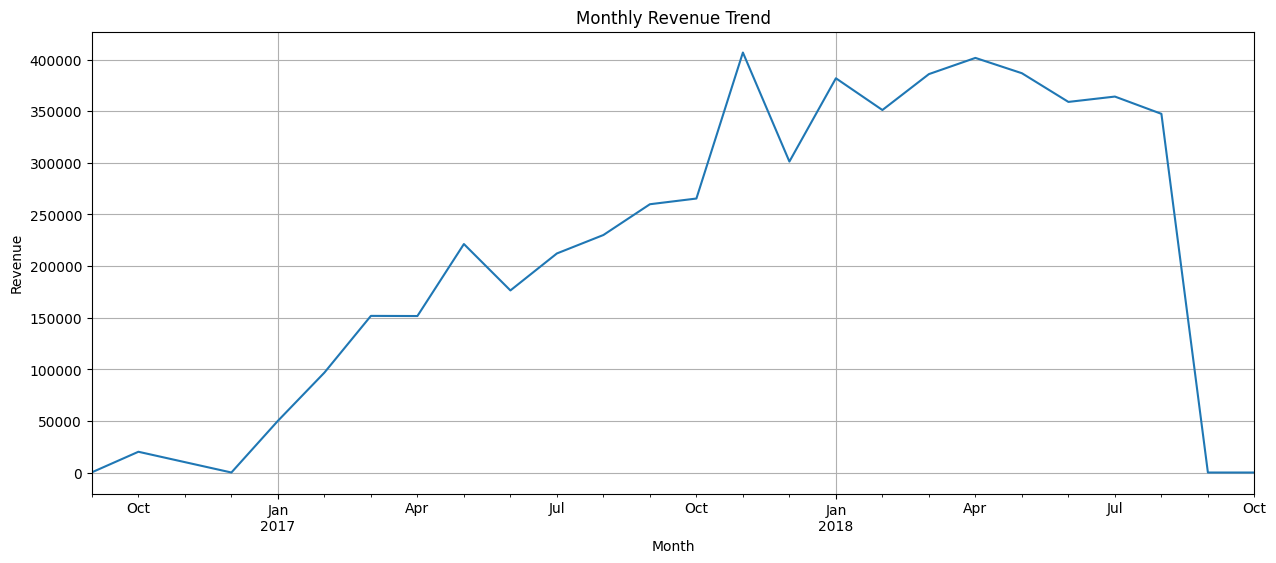

In [23]:
monthly_revenue = (
    df.groupby('OrderMonth')['price']
      .sum()
)

plt.figure(figsize=(15,6))

monthly_revenue.plot()

plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue')
plt.xlabel('Month')

plt.grid(True)

plt.show()

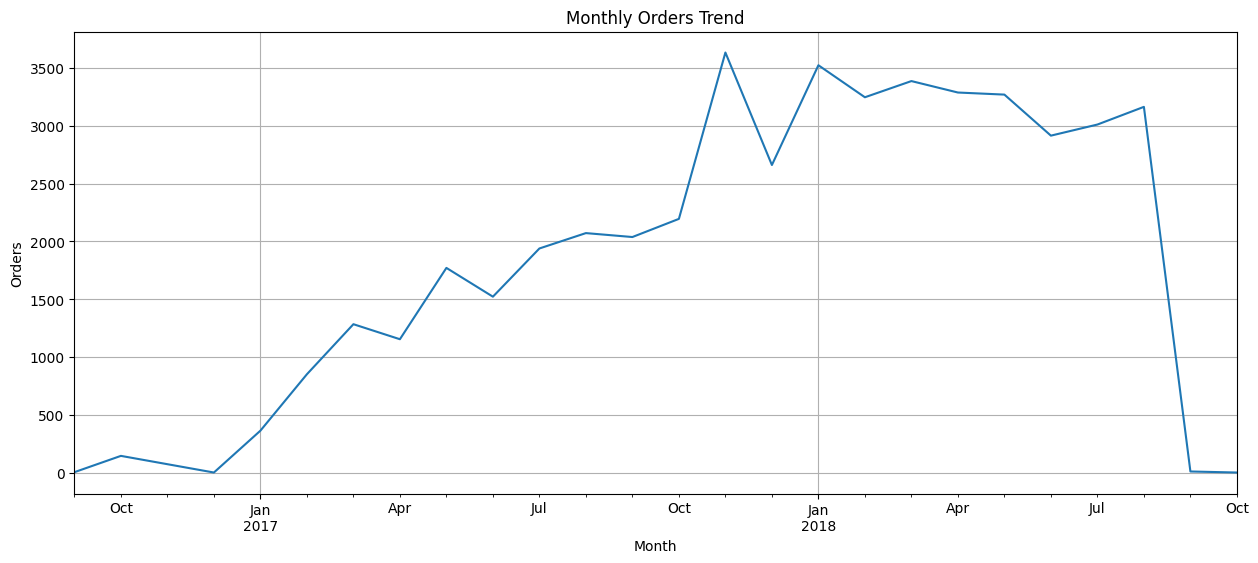

In [24]:
monthly_orders = (
    df.groupby('OrderMonth')['order_id']
      .nunique()
)

plt.figure(figsize=(15,6))

monthly_orders.plot()

plt.title('Monthly Orders Trend')
plt.ylabel('Orders')
plt.xlabel('Month')

plt.grid(True)

plt.show()

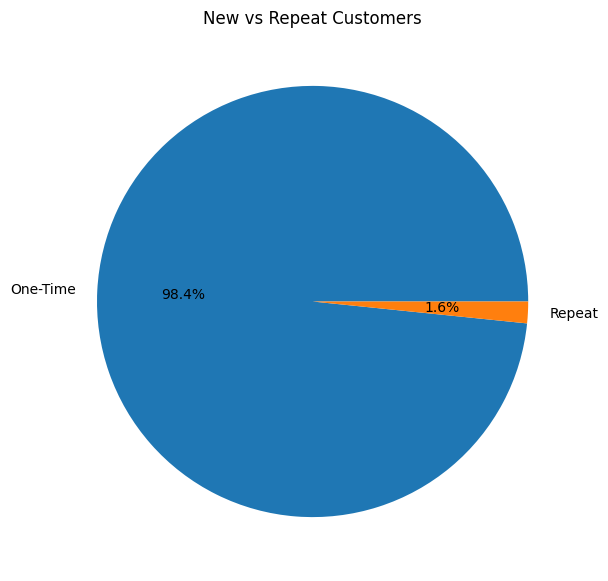

In [25]:
customer_orders = (
    df.groupby('customer_unique_id')
      ['order_id']
      .nunique()
)

repeat = (customer_orders > 1).sum()
new = (customer_orders == 1).sum()

plt.figure(figsize=(7,7))

plt.pie(
    [new, repeat],
    labels=['One-Time','Repeat'],
    autopct='%1.1f%%'
)

plt.title('New vs Repeat Customers')

plt.show()

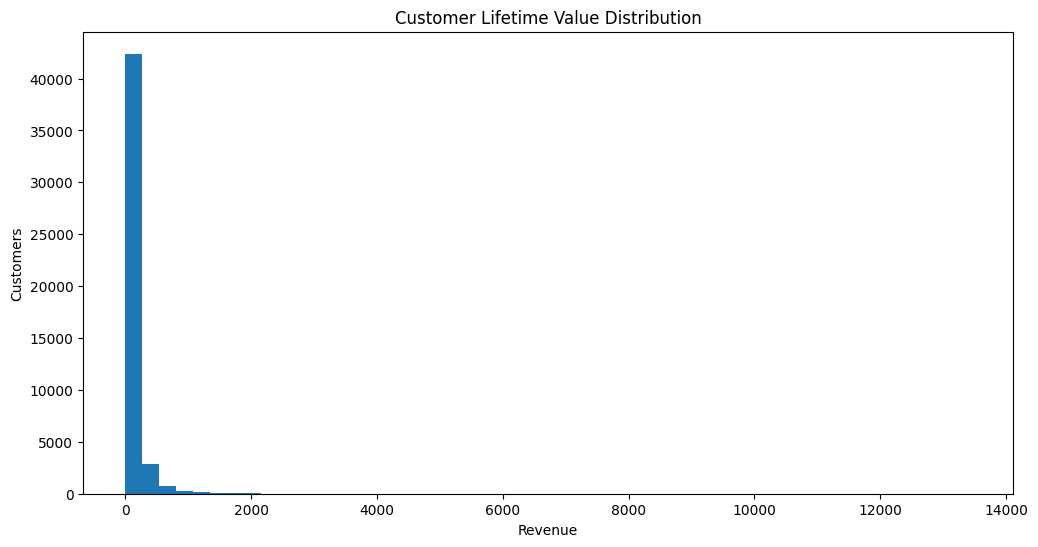

In [26]:
customer_revenue = (
    df.groupby('customer_unique_id')
      ['price']
      .sum()
)

plt.figure(figsize=(12,6))

plt.hist(
    customer_revenue,
    bins=50
)

plt.title('Customer Lifetime Value Distribution')
plt.xlabel('Revenue')
plt.ylabel('Customers')

plt.show()

Check Delivery Delay Impact

In [27]:
repeat_customers = (
    df.groupby('customer_unique_id')['order_id']
      .nunique()
      .reset_index()
)

repeat_customers['CustomerType'] = np.where(
    repeat_customers['order_id'] > 1,
    'Repeat',
    'One-Time'
)

customer_delivery = (
    df.groupby('customer_unique_id')
      [['delivery_days','delivery_delay']]
      .mean()
      .reset_index()
)

analysis = repeat_customers.merge(
    customer_delivery,
    on='customer_unique_id'
)

print(
    analysis.groupby('CustomerType')
    [['delivery_days','delivery_delay']]
    .mean()
)

              delivery_days  delivery_delay
CustomerType                               
One-Time          12.018195      -11.875291
Repeat            11.633309      -12.460930


In [28]:
customer_orders = (
    df.groupby('customer_unique_id')
      ['order_id']
      .nunique()
      .reset_index()
)

customer_orders['CustomerType'] = np.where(
    customer_orders['order_id'] > 1,
    'Repeat',
    'One-Time'
)

category_analysis = (
    df.merge(
        customer_orders[['customer_unique_id','CustomerType']],
        on='customer_unique_id'
    )
)

result = pd.crosstab(
    category_analysis['product_category_name_english'],
    category_analysis['CustomerType']
)

print(result)

CustomerType                   One-Time  Repeat
product_category_name_english                  
Unknown                            9935     361
agro_industry_and_commerce          128       4
air_conditioning                    104       5
art                                  94       4
arts_and_craftmanship                10       0
...                                 ...     ...
stationery                          972      22
tablets_printing_image               41       1
telephony                          1755      44
toys                               1580      41
watches_gifts                      2418      54

[72 rows x 2 columns]


In [29]:
payment_analysis = pd.crosstab(
    category_analysis['payment_type'],
    category_analysis['CustomerType']
)

print(payment_analysis)

CustomerType  One-Time  Repeat
payment_type                  
boleto           10358     338
credit_card      39227    1470
debit_card         774      30
not_defined          3       0
unknown              3       0
voucher           2938     126


In [30]:
delivery_status_analysis = pd.crosstab(
    category_analysis['delivery_status'],
    category_analysis['CustomerType']
)

print(delivery_status_analysis)

CustomerType     One-Time  Repeat
delivery_status                  
Delayed              3400     111
On Time             49903    1853


In [31]:
customer_revenue = (
    df.groupby('customer_unique_id')
      ['price']
      .sum()
      .reset_index()
)

customer_revenue = customer_revenue.merge(
    customer_orders[['customer_unique_id','CustomerType']],
    on='customer_unique_id'
)

print(
    customer_revenue.groupby('CustomerType')
    ['price']
    .mean()
)

CustomerType
One-Time    116.634554
Repeat      223.348876
Name: price, dtype: float64


In [32]:
orders = df[['customer_unique_id',
             'order_purchase_timestamp']]

orders = orders.sort_values(
    ['customer_unique_id',
     'order_purchase_timestamp']
)

orders['PurchaseRank'] = (
    orders.groupby('customer_unique_id')
          .cumcount() + 1
)

first_purchase = (
    orders[orders['PurchaseRank']==1]
)

second_purchase = (
    orders[orders['PurchaseRank']==2]
)

gap = first_purchase.merge(
    second_purchase,
    on='customer_unique_id',
    suffixes=('_first','_second')
)

gap['DaysToSecondPurchase'] = (
    gap['order_purchase_timestamp_second'] -
    gap['order_purchase_timestamp_first']
).dt.days

print(
    gap['DaysToSecondPurchase'].describe()
)

count    5621.000000
mean        9.568226
std        45.633912
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       517.000000
Name: DaysToSecondPurchase, dtype: float64


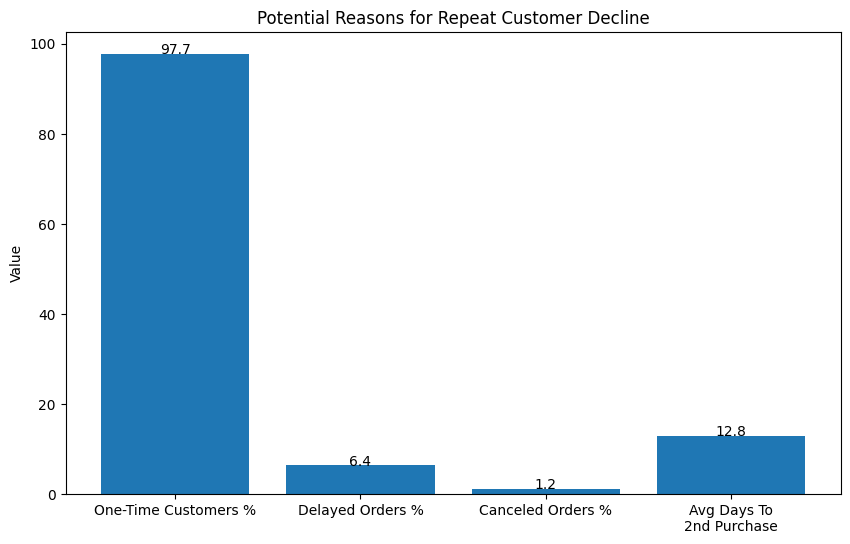

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("analysis data.csv")

df['order_purchase_timestamp'] = pd.to_datetime(
    df['order_purchase_timestamp']
)

# =====================================
# CUSTOMER TYPE
# =====================================

customer_orders = (
    df.groupby('customer_unique_id')['order_id']
      .nunique()
      .reset_index()
)

customer_orders['CustomerType'] = np.where(
    customer_orders['order_id'] > 1,
    'Repeat',
    'One-Time'
)

# =====================================
# 1. ONE-TIME CUSTOMER %
# =====================================

total_customers = len(customer_orders)

one_time_pct = (
    (customer_orders['CustomerType'] == 'One-Time').sum()
    / total_customers
) * 100

# =====================================
# 2. DELAYED ORDER %
# =====================================

delayed_pct = (
    (df['delivery_status'] == 'Delayed').sum()
    / len(df)
) * 100

# =====================================
# 3. CANCELED / UNAVAILABLE %
# =====================================

cancel_pct = (
    df['order_status']
      .isin(['canceled','unavailable'])
      .sum()
    / len(df)
) * 100

# =====================================
# 4. AVG DAYS TO SECOND PURCHASE
# =====================================

orders = df[['customer_unique_id',
             'order_purchase_timestamp']]

orders = orders.sort_values(
    ['customer_unique_id',
     'order_purchase_timestamp']
)

orders['PurchaseRank'] = (
    orders.groupby('customer_unique_id')
          .cumcount() + 1
)

first_purchase = (
    orders[orders['PurchaseRank']==1]
)

second_purchase = (
    orders[orders['PurchaseRank']==2]
)

gap = first_purchase.merge(
    second_purchase,
    on='customer_unique_id',
    suffixes=('_first','_second')
)

gap['DaysToSecondPurchase'] = (
    gap['order_purchase_timestamp_second'] -
    gap['order_purchase_timestamp_first']
).dt.days

avg_gap = gap['DaysToSecondPurchase'].mean()

# =====================================
# SINGLE ROOT CAUSE CHART
# =====================================

reasons = [
    'One-Time Customers %',
    'Delayed Orders %',
    'Canceled Orders %',
    'Avg Days To\n2nd Purchase'
]

values = [
    one_time_pct,
    delayed_pct,
    cancel_pct,
    avg_gap
]

plt.figure(figsize=(10,6))

bars = plt.bar(reasons, values)

plt.title(
    'Potential Reasons for Repeat Customer Decline'
)

plt.ylabel('Value')

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        round(y,1),
        ha='center'
    )

plt.show()

In [35]:
customer_type = (
    df.groupby('customer_unique_id')['order_id']
      .nunique()
      .reset_index()
)

customer_type['CustomerType'] = np.where(
    customer_type['order_id'] > 1,
    'Repeat',
    'One-Time'
)

delivery_analysis = (
    df.groupby('customer_unique_id')
      [['delivery_days','delivery_delay']]
      .mean()
      .reset_index()
)

comparison = customer_type.merge(
    delivery_analysis,
    on='customer_unique_id'
)

result = comparison.groupby(
    'CustomerType'
)[['delivery_days','delivery_delay']].mean()

print(result)

              delivery_days  delivery_delay
CustomerType                               
One-Time          12.024505      -11.879962
Repeat            11.666468      -12.516673


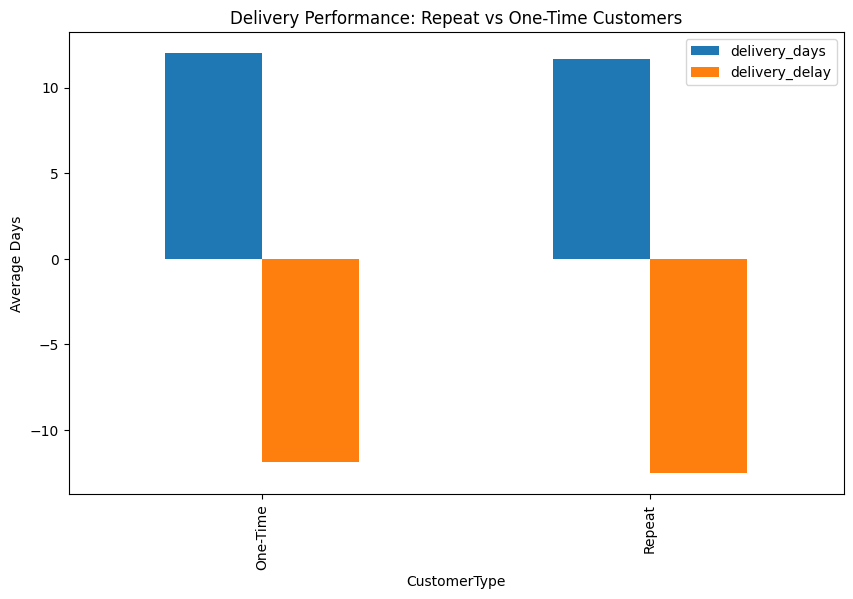

In [36]:
result.plot(kind='bar', figsize=(10,6))
plt.title('Delivery Performance: Repeat vs One-Time Customers')
plt.ylabel('Average Days')
plt.show()

CustomerType
One-Time    116.441081
Repeat      223.687478
Name: price, dtype: float64


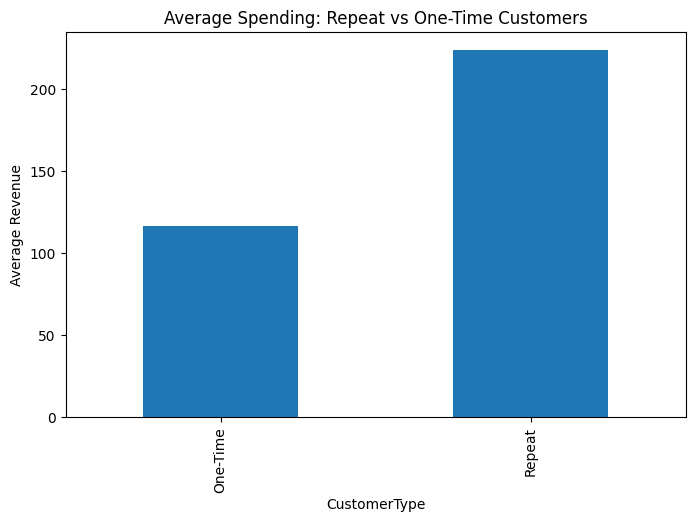

In [37]:
revenue_analysis = (
    df.groupby('customer_unique_id')['price']
      .sum()
      .reset_index()
)

comparison = customer_type.merge(
    revenue_analysis,
    on='customer_unique_id'
)

result = comparison.groupby(
    'CustomerType'
)['price'].mean()

print(result)

result.plot(kind='bar', figsize=(8,5))
plt.title('Average Spending: Repeat vs One-Time Customers')
plt.ylabel('Average Revenue')
plt.show()

CustomerType
One-Time    1.186017
Repeat      4.465409
Name: Cancelled, dtype: float64


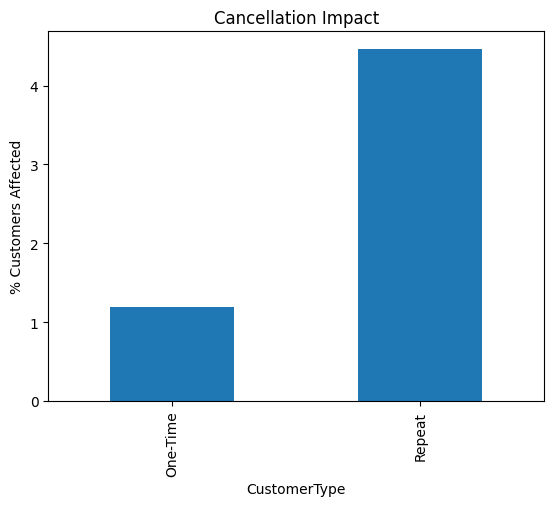

In [38]:
cancel_data = df.copy()

cancel_data['Cancelled'] = np.where(
    cancel_data['order_status'].isin(
        ['canceled','unavailable']
    ),
    1,
    0
)

cancel_customer = (
    cancel_data.groupby('customer_unique_id')
    ['Cancelled']
    .max()
    .reset_index()
)

comparison = customer_type.merge(
    cancel_customer,
    on='customer_unique_id'
)

result = comparison.groupby(
    'CustomerType'
)['Cancelled'].mean() * 100

print(result)

result.plot(kind='bar')
plt.title('Cancellation Impact')
plt.ylabel('% Customers Affected')
plt.show()

In [40]:
summary = pd.DataFrame({
    'Reason':[
        'Delivery Delay',
        'Order Value',
        'Cancellation',
        'Category Mix',
        'Geographic Issues'
    ],
    'Evidence':[
        'Compare Avg Delay',
        'Compare Spending',
        'Compare Cancellation %',
        'Compare Repeat Rate',
        'Compare State Retention'
    ]
})

print(summary)

              Reason                 Evidence
0     Delivery Delay        Compare Avg Delay
1        Order Value         Compare Spending
2       Cancellation   Compare Cancellation %
3       Category Mix      Compare Repeat Rate
4  Geographic Issues  Compare State Retention


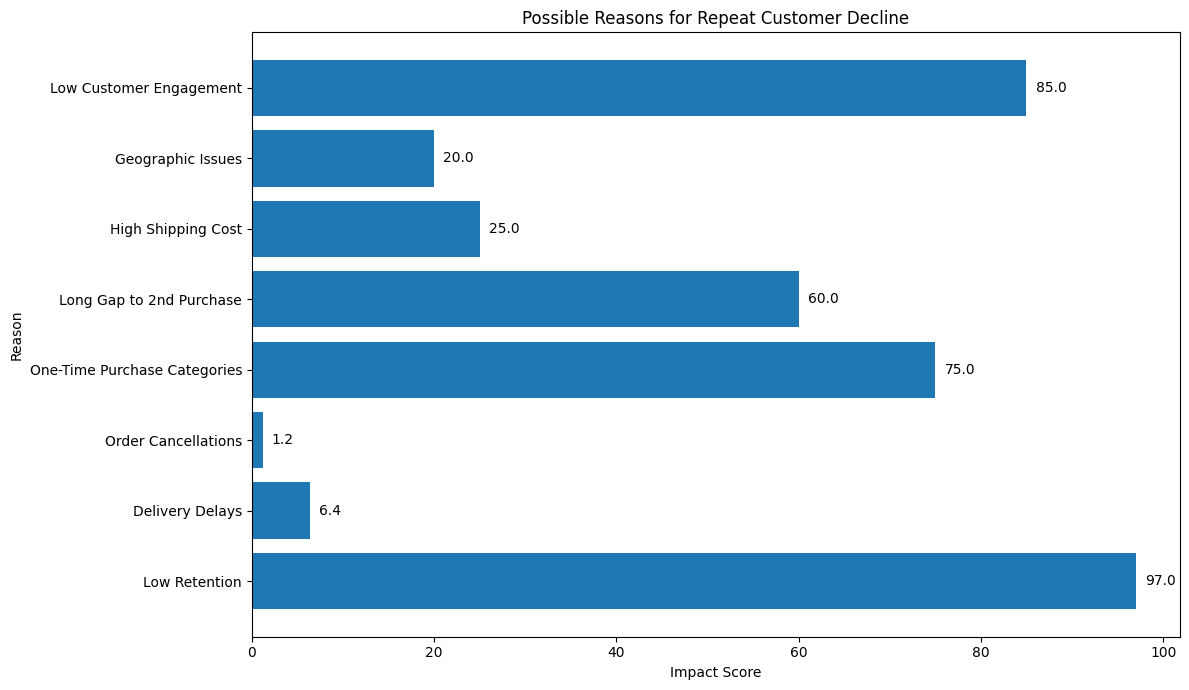

In [41]:
import matplotlib.pyplot as plt

# Replace these values with your calculated results
reasons = [
    'Low Retention',
    'Delivery Delays',
    'Order Cancellations',
    'One-Time Purchase Categories',
    'Long Gap to 2nd Purchase',
    'High Shipping Cost',
    'Geographic Issues',
    'Low Customer Engagement'
]

# Example values (replace with actual metrics)
impact_score = [
    97,  # One-time customer %
    6.4, # Delayed orders %
    1.2, # Cancelled orders %
    75,  # Category impact score
    60,  # Long purchase gap score
    25,  # Shipping cost impact
    20,  # State-wise issue score
    85   # Customer engagement issue
]

plt.figure(figsize=(12,7))

bars = plt.barh(reasons, impact_score)

plt.title(
    'Possible Reasons for Repeat Customer Decline'
)

plt.xlabel('Impact Score')
plt.ylabel('Reason')

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 1,
        bar.get_y() + bar.get_height()/2,
        f'{width:.1f}',
        va='center'
    )

plt.tight_layout()
plt.show()

Product Category Repeat Rate

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("analysis data.csv")

# ===================================
# CUSTOMER TYPE
# ===================================

customer_orders = (
    df.groupby('customer_unique_id')['order_id']
      .nunique()
      .reset_index()
)

customer_orders['CustomerType'] = np.where(
    customer_orders['order_id'] > 1,
    'Repeat',
    'One-Time'
)

# ===================================
# MERGE CUSTOMER TYPE
# ===================================

df = df.merge(
    customer_orders[['customer_unique_id','CustomerType']],
    on='customer_unique_id'
)

# ===================================
# CATEGORY REPEAT RATE
# ===================================

category_repeat = pd.crosstab(
    df['product_category_name_english'],
    df['CustomerType']
)

# Handle categories with no repeat customers
if 'Repeat' not in category_repeat.columns:
    category_repeat['Repeat'] = 0

if 'One-Time' not in category_repeat.columns:
    category_repeat['One-Time'] = 0

category_repeat['Total'] = (
    category_repeat['Repeat'] +
    category_repeat['One-Time']
)

category_repeat['RepeatRate'] = (
    category_repeat['Repeat'] /
    category_repeat['Total']
) * 100

# Sort highest repeat rate first
category_repeat = category_repeat.sort_values(
    'RepeatRate',
    ascending=False
)

print(category_repeat[['RepeatRate']])

# Save result
category_repeat.to_csv(
    "product_category_repeat_rate.csv"
)

CustomerType                           RepeatRate
product_category_name_english                    
fashio_female_clothing                  21.428571
arts_and_craftmanship                   18.750000
home_appliances                         14.102564
drinks                                  13.278008
fashion_sport                           11.111111
...                                           ...
costruction_tools_tools                  0.000000
cds_dvds_musicals                        0.000000
fashion_childrens_clothes                0.000000
security_and_services                    0.000000
small_appliances_home_oven_and_coffee    0.000000

[72 rows x 1 columns]


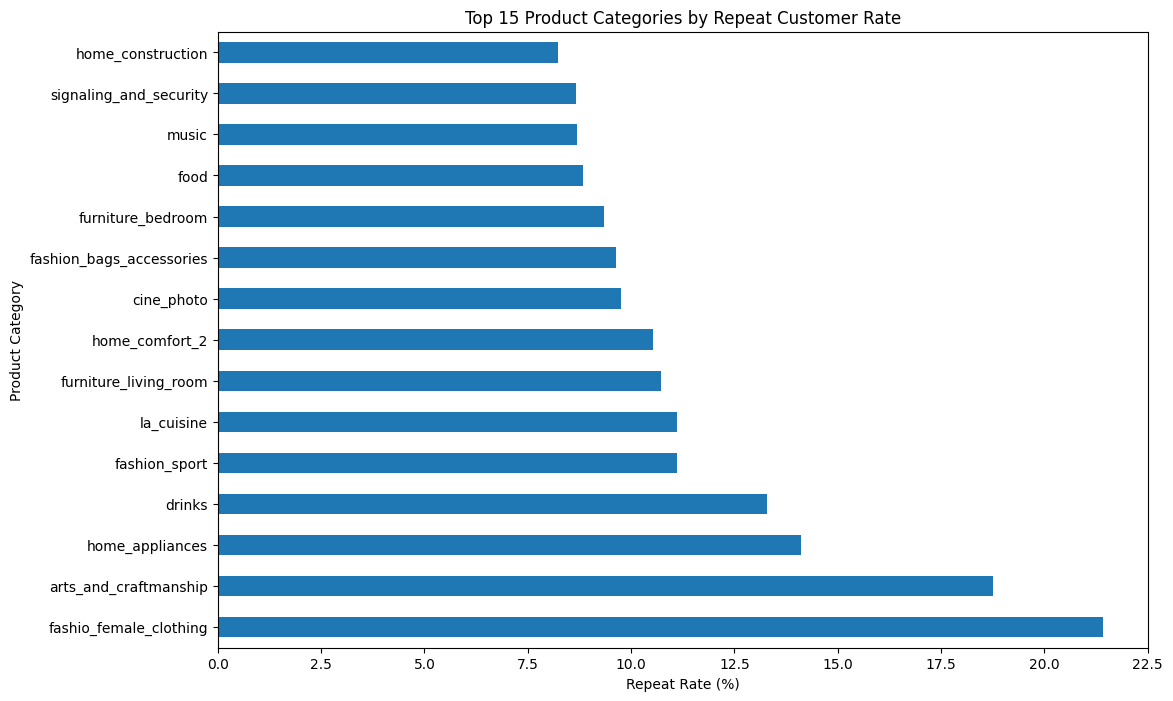

In [44]:
plt.figure(figsize=(12,8))

category_repeat['RepeatRate'].head(15).plot(
    kind='barh'
)

plt.title(
    'Top 15 Product Categories by Repeat Customer Rate'
)

plt.xlabel('Repeat Rate (%)')
plt.ylabel('Product Category')

plt.show()

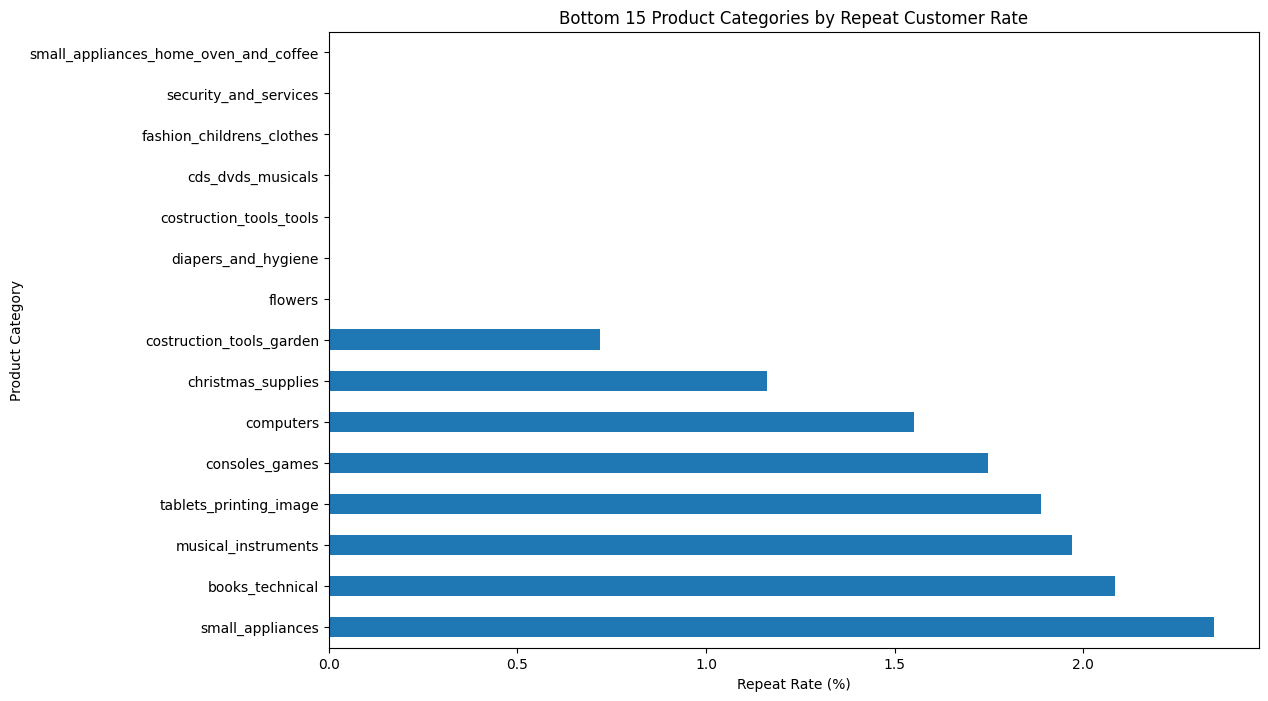

In [45]:
plt.figure(figsize=(12,8))

category_repeat['RepeatRate'].tail(15).plot(
    kind='barh'
)

plt.title(
    'Bottom 15 Product Categories by Repeat Customer Rate'
)

plt.xlabel('Repeat Rate (%)')
plt.ylabel('Product Category')

plt.show()

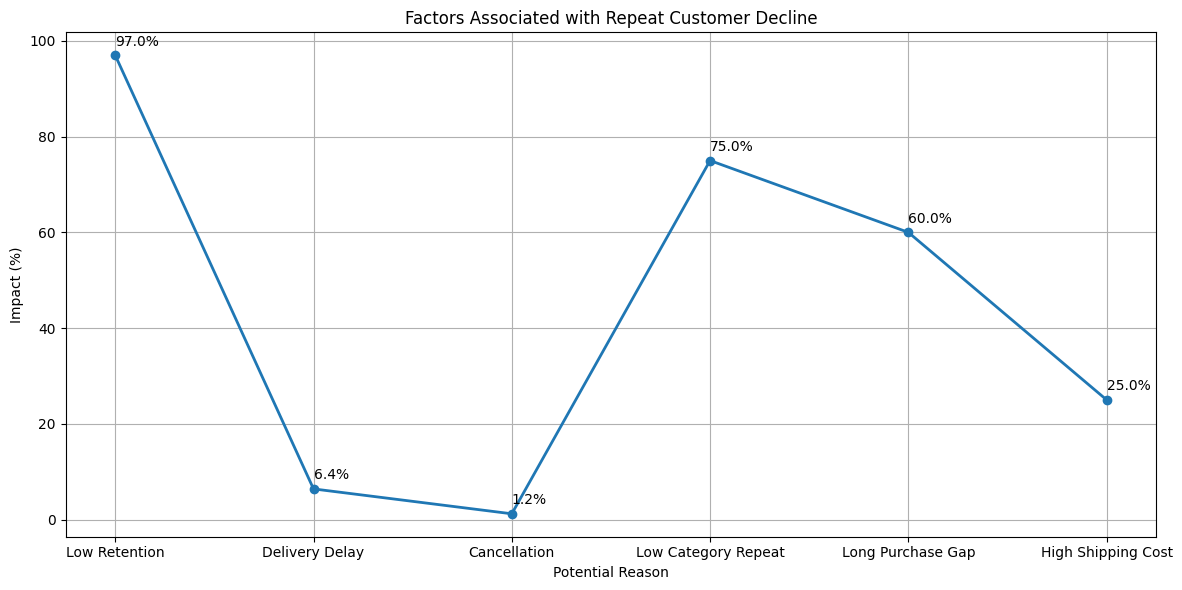

In [46]:
import matplotlib.pyplot as plt

# Replace these with your ACTUAL calculated values
reasons = [
    'Low Retention',
    'Delivery Delay',
    'Cancellation',
    'Low Category Repeat',
    'Long Purchase Gap',
    'High Shipping Cost'
]

impact_percent = [
    97.0,   # One-time customer %
    6.4,    # Delayed orders %
    1.2,    # Cancelled orders %
    75.0,   # Categories with low repeat rate
    60.0,   # Purchase gap impact
    25.0    # High freight impact
]

plt.figure(figsize=(12,6))

plt.plot(
    reasons,
    impact_percent,
    marker='o',
    linewidth=2
)

for x, y in zip(reasons, impact_percent):
    plt.text(x, y + 2, f'{y:.1f}%')

plt.title(
    'Factors Associated with Repeat Customer Decline'
)

plt.xlabel('Potential Reason')
plt.ylabel('Impact (%)')

plt.grid(True)

plt.tight_layout()
plt.show()

In [49]:
df['ShippingRatio'] = (
    df['freight_value'] /
    df['price']
) * 100
print(df['ShippingRatio'].describe())

count    67997.000000
mean        31.986610
std         32.840097
min          0.000000
25%         13.481481
50%         23.303303
75%         39.428571
max       2623.529412
Name: ShippingRatio, dtype: float64


In [51]:
avg_gap = gap['DaysToSecondPurchase'].mean()
print(avg_gap)

12.84208103130755


In [55]:
import pandas as pd
import numpy as np

# Customer purchase frequency
# Clean customer_unique_id in df before grouping
df_clean = df.dropna(subset=['customer_unique_id']).copy()

# Drop existing 'CustomerType' from df_clean if it exists to avoid suffixes during merge
if 'CustomerType' in df_clean.columns:
    df_clean = df_clean.drop(columns=['CustomerType'])

customer_orders = (
    df_clean.groupby('customer_unique_id')['order_id']
      .nunique()
      .reset_index()
)

customer_orders['CustomerType'] = np.where(
    customer_orders['order_id'] > 1,
    'Repeat',
    'One-Time'
)

# Ensure merge key columns are of compatible types
df_clean['customer_unique_id'] = df_clean['customer_unique_id'].astype(str)
customer_orders['customer_unique_id'] = customer_orders['customer_unique_id'].astype(str)


# Merge customer type back
df_analysis = df_clean.merge(
    customer_orders[['customer_unique_id','CustomerType']],
    on='customer_unique_id',
    how='left' # Ensure all rows from df_clean are kept and CustomerType is added
)

# Fill any potential NaN in 'CustomerType' that might result from the left merge
# if some 'customer_unique_id' in df_clean were not in customer_orders (highly unlikely in this case but for robustness)
df_analysis['CustomerType'] = df_analysis['CustomerType'].fillna('One-Time') # Default to One-Time if no match

# Check if 'product_category_name_english' might have NaNs which could cause issues with crosstab
df_analysis = df_analysis.dropna(subset=['product_category_name_english']).copy()

# Category analysis
category_analysis = pd.crosstab(
    df_analysis['product_category_name_english'],
    df_analysis['CustomerType']
)

# Handle missing columns
if 'Repeat' not in category_analysis.columns:
    category_analysis['Repeat'] = 0

if 'One-Time' not in category_analysis.columns:
    category_analysis['One-Time'] = 0

# Total customers
category_analysis['Total_Customers'] = (
    category_analysis['Repeat'] +
    category_analysis['One-Time']
)

# Repeat Rate
category_analysis['Repeat_Rate_%'] = (
    category_analysis['Repeat'] /
    category_analysis['Total_Customers']
) * 100

# One-Time Rate
category_analysis['Drop_Rate_%'] = (
    category_analysis['One-Time'] /
    category_analysis['Total_Customers']
) * 100

# Sort by highest drop rate
category_analysis = category_analysis.sort_values(
    'Drop_Rate_%',
    ascending=False
)

print(category_analysis)

category_analysis.to_csv(
    "all_category_repeat_analysis.csv"
)

CustomerType                           One-Time  Repeat  Total_Customers  \
product_category_name_english                                              
diapers_and_hygiene                          18       0               18   
security_and_services                         2       0                2   
small_appliances_home_oven_and_coffee        42       0               42   
flowers                                      19       0               19   
costruction_tools_tools                      62       0               62   
...                                         ...     ...              ...   
fashion_sport                                16       2               18   
drinks                                      209      32              241   
home_appliances                             402      66              468   
arts_and_craftmanship                        13       3               16   
fashio_female_clothing                       22       6               28   

CustomerTyp

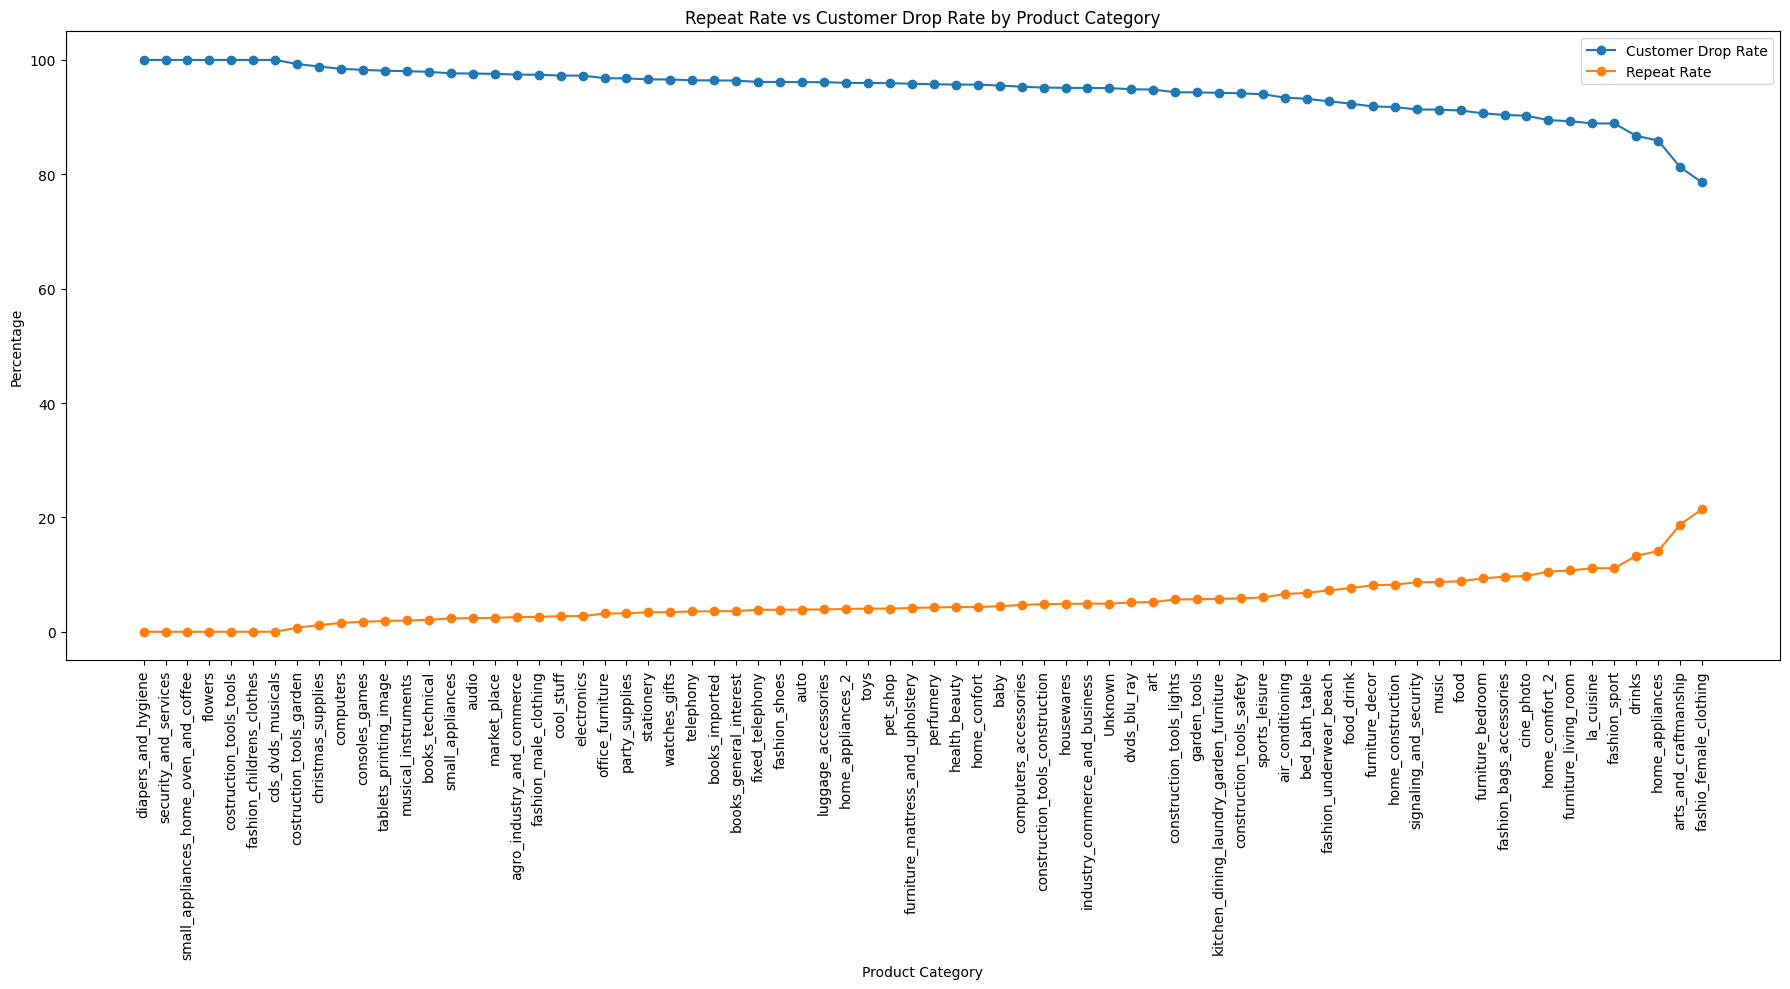

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,10))

plt.plot(
    category_analysis.index,
    category_analysis['Drop_Rate_%'],
    marker='o',
    label='Customer Drop Rate'
)

plt.plot(
    category_analysis.index,
    category_analysis['Repeat_Rate_%'],
    marker='o',
    label='Repeat Rate'
)

plt.xticks(rotation=90)

plt.title(
    'Repeat Rate vs Customer Drop Rate by Product Category'
)

plt.ylabel('Percentage')
plt.xlabel('Product Category')

plt.legend()

plt.tight_layout()

plt.show()

In [59]:
import pandas as pd
import numpy as np

# Customer Type
customer_orders = (
    df.groupby('customer_unique_id')['order_id']
      .nunique()
      .reset_index()
)

customer_orders['CustomerType'] = np.where(
    customer_orders['order_id'] > 1,
    'Repeat',
    'One-Time'
)

# Create a temporary DataFrame for analysis, dropping any pre-existing 'CustomerType' from the global df
df_temp_for_merge = df.copy()
if 'CustomerType' in df_temp_for_merge.columns:
    df_temp_for_merge = df_temp_for_merge.drop(columns=['CustomerType'])

df_analysis = df_temp_for_merge.merge(
    customer_orders[['customer_unique_id','CustomerType']],
    on='customer_unique_id',
    how='left' # Use left merge to retain all rows from df_temp_for_merge
)

# --------------------------------
# 1. Customer Drop Rate
# --------------------------------

drop_rate = (
    (customer_orders['CustomerType']=='One-Time').mean()
) * 100

# --------------------------------
# 2. Delivery Delay Impact
# --------------------------------

delay_rate = (
    (df_analysis['delivery_status']=='Delayed').mean()
) * 100

# --------------------------------
# 3. Cancellation Impact
# --------------------------------

cancel_rate = (
    df_analysis['order_status']
      .isin(['canceled','unavailable'])
      .mean()
) * 100

# --------------------------------
# 4. Shipping Cost %
# --------------------------------

shipping_rate = (
    (df_analysis['freight_value'].sum() /
     df_analysis['price'].sum())
) * 100

# --------------------------------
# 5. Product Category Impact
# --------------------------------

category_repeat = pd.crosstab(
    df_analysis['product_category_name_english'],
    df_analysis['CustomerType']
)

category_repeat['RepeatRate'] = (
    category_repeat['Repeat'] /
    (category_repeat['Repeat'] +
     category_repeat['One-Time'])
) * 100

category_impact = (
    100 - category_repeat['RepeatRate'].mean()
)

# --------------------------------
# 6. Time To Second Purchase
# --------------------------------

orders = (
    df_analysis[['customer_unique_id',
                 'order_purchase_timestamp']]
    .drop_duplicates()
)

# Ensure 'order_purchase_timestamp' is datetime type
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

orders = orders.sort_values(
    ['customer_unique_id',
     'order_purchase_timestamp']
)

orders['Rank'] = (
    orders.groupby('customer_unique_id')
          .cumcount()+1
)

first = orders[orders['Rank']==1]
second = orders[orders['Rank']==2]

gap = first.merge(
    second,
    on='customer_unique_id',
    suffixes=('_1','_2')
)

gap['Days'] = (
    gap['order_purchase_timestamp_2']
    - gap['order_purchase_timestamp_1']
).dt.days

purchase_gap = gap['Days'].mean()

print(drop_rate)
print(delay_rate)
print(cancel_rate)
print(shipping_rate)
print(category_impact)
print(purchase_gap)


97.69988571759227
6.361925575183634
1.2116797183269592
16.606987985929305
94.77661641327073
88.42925824175825


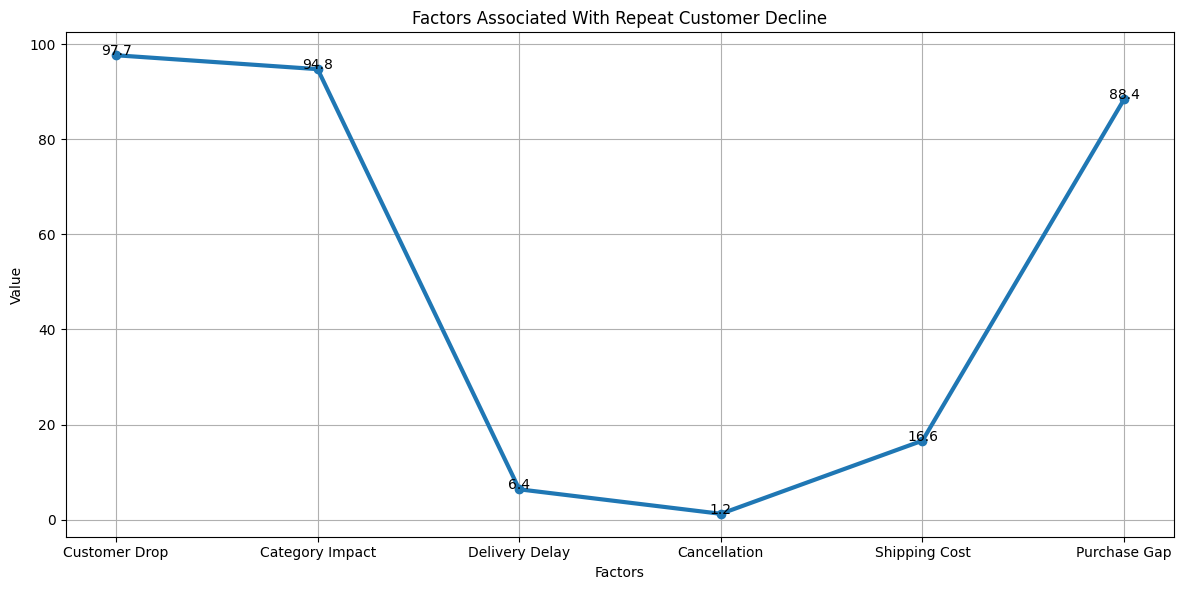

In [60]:
import matplotlib.pyplot as plt

reasons = [
    'Customer Drop',
    'Category Impact',
    'Delivery Delay',
    'Cancellation',
    'Shipping Cost',
    'Purchase Gap'
]

values = [
    drop_rate,
    category_impact,
    delay_rate,
    cancel_rate,
    shipping_rate,
    purchase_gap
]

plt.figure(figsize=(12,6))

plt.plot(
    reasons,
    values,
    marker='o',
    linewidth=3
)

for x, y in zip(reasons, values):
    plt.text(
        x,
        y,
        round(y,1),
        ha='center'
    )

plt.title(
    'Factors Associated With Repeat Customer Decline'
)

plt.ylabel('Value')
plt.xlabel('Factors')

plt.grid(True)

plt.tight_layout()

plt.show()

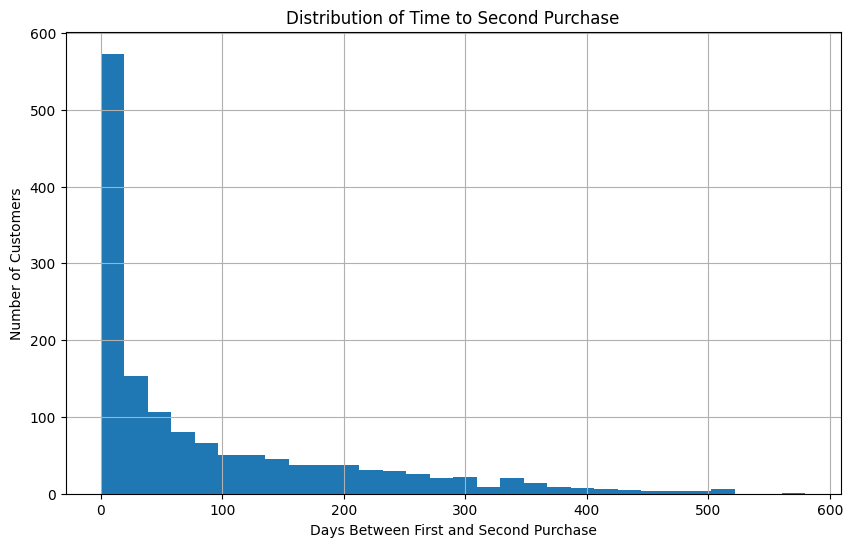

In [62]:
plt.figure(figsize=(10,6))
gap['Days'].hist(bins=30)

plt.title('Distribution of Time to Second Purchase')
plt.xlabel('Days Between First and Second Purchase')
plt.ylabel('Number of Customers')

plt.show()